In [1]:
!pip install --quiet --no-deps recbole==1.2.1
!pip install --quiet colorlog pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.2 MB/s eta 0:00:0000:010:01


In [3]:
import os
import sys
import time
import pickle
import logging
import warnings
import ast
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.init import xavier_uniform_
from torch.utils.tensorboard import SummaryWriter
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
from sklearn.model_selection import ParameterGrid
from recbole.config import Config
from recbole.trainer import Trainer
from recbole.utils import init_seed
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender.lightgcn import LightGCN
from recbole.model.general_recommender.neumf import NeuMF
from recbole.model.layers import MLPLayers

if not hasattr(np, 'float_'): np.float_ = np.float64
if not hasattr(np, 'int_'): np.int_ = np.int64
if not hasattr(np, 'bool_'): np.bool_ = np.bool_
if not hasattr(np, 'complex_'): np.complex_ = np.complex128
if not hasattr(np, 'object_'): np.object_ = np.object_
if not hasattr(np, 'str_'): np.str_ = np.str_
if not hasattr(np, 'unicode_'): np.unicode_ = np.str_
if not hasattr(np, 'long'): np.long = np.int64
if not hasattr(np, 'unicode'): np.unicode = np.str_

if hasattr(scipy.sparse, 'dok_matrix') and not hasattr(scipy.sparse.dok_matrix, '_update'):
    def _dok_update(self, other):
        if scipy.sparse.issparse(other):
            other = other.todok()
        for (i, j), v in other.items():
            self[i, j] = v
    scipy.sparse.dok_matrix._update = _dok_update

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

os.environ['TORCH_FORCE_WEIGHTS_ONLY_LOAD'] = '0'
original_load = torch.load
def safe_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return original_load(*args, **kwargs)
torch.load = safe_load

logging.basicConfig(level=logging.WARNING, format='%(asctime)s - %(message)s')
logger = logging.getLogger()

RESULTS_DIR = '/kaggle/working/results/'
LOG_DIR = '/kaggle/working/tensorboard_logs/'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

2026-05-17 09:32:23.742569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779010343.939710      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779010343.996170      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779010344.497202      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779010344.497235      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779010344.497238      57 computation_placer.cc:177] computation placer alr

# Предобработка данных 

**Слияние датасетов**

In [ ]:
logging.getLogger('sentence_transformers').setLevel(logging.ERROR)
logging.getLogger('httpx').setLevel(logging.ERROR)
logging.getLogger('httpcore').setLevel(logging.ERROR)
logging.getLogger('filelock').setLevel(logging.ERROR)
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

ML_PATH = '/kaggle/input/datasets/organizations/grouplens/movielens-20m-dataset/'
TMDB_PATH = '/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/'

ratings = pd.read_csv(f'{ML_PATH}rating.csv')
movies_ml = pd.read_csv(f'{ML_PATH}movie.csv')
links = pd.read_csv(f'{ML_PATH}link.csv')
tmdb = pd.read_csv(f'{TMDB_PATH}tmdb_5000_movies.csv')

links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce').astype('Int64')
tmdb['id'] = tmdb['id'].astype('Int64')

merged = links.merge(
    tmdb[['id', 'original_title', 'genres', 'overview', 'popularity']], 
    left_on='tmdbId', right_on='id', how='inner'
)
merged = merged.merge(
    movies_ml[['movieId', 'title']].rename(columns={'title': 'ml_title'}), 
    on='movieId', how='inner'
)
merged.dropna(subset=['tmdbId'], inplace=True)
merged.drop_duplicates(subset='movieId', keep='first', inplace=True)

def parse_genres(json_str):
    if not isinstance(json_str, str) or len(json_str) < 3: 
        return []
    try:
        parsed = ast.literal_eval(json_str)
        return [g['name'] for g in parsed if isinstance(g, dict) and 'name' in g]
    except:
        return []

merged['genre_list'] = merged['genres'].apply(parse_genres)
merged['overview'] = merged['overview'].fillna('').str.replace(r'<[^>]+>', '', regex=True).str.strip()
merged['text_for_emb'] = merged.apply(
    lambda row: f"{row['original_title']}. {row['overview']}" if len(row['overview']) > 10 else str(row['original_title']), 
    axis=1
).str.slice(0, 450)
merged['popularity_norm'] = StandardScaler().fit_transform(np.log1p(merged[['popularity']]).values).ravel()

mlb = MultiLabelBinarizer()
genre_df = pd.DataFrame(mlb.fit_transform(merged['genre_list']), columns=mlb.classes_, index=merged.index)

sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
emb_matrix = sbert.encode(merged['text_for_emb'].tolist(), batch_size=256, show_progress_bar=False)
emb_df = pd.DataFrame(emb_matrix, columns=[f'sbert_{i}' for i in range(emb_matrix.shape[1])], index=merged.index)

item_features = pd.concat([genre_df, emb_df], axis=1)
item_features['popularity_norm'] = merged['popularity_norm'].values
item_features.index = merged['movieId']

OUT_DIR = '/kaggle/working/'
ratings[ratings['movieId'].isin(item_features.index)].to_parquet(f'{OUT_DIR}interactions.parquet', index=False)
item_features.to_parquet(f'{OUT_DIR}item_features.parquet')
with open(f'{OUT_DIR}genre_classes.pkl', 'wb') as f:
    pickle.dump(mlb.classes_, f)

Вывод содержимого полученных датасетов после слияния:

In [38]:
from IPython.display import display

display(merged.head())
display(pd.read_parquet('/kaggle/working/interactions.parquet').head())
display(pd.read_parquet('/kaggle/working/item_features.parquet').head())

interactions = pd.read_parquet('/kaggle/working/interactions.parquet')
item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
print(f"Interactions: {len(interactions):,} rows")
print(f"Item features: {len(item_features):,} rows x {len(item_features.columns)} columns")

,movieId,imdbId,tmdbId,id,original_title,genres,overview,popularity,ml_title,genre_list,text_for_emb,popularity_norm
0,1,114709,862,862,Toy Story,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 35, ""...","Led by Woody, Andy's toys live happily in his ...",73.640445,Toy Story (1995),"[Animation, Comedy, Family]","Toy Story. Led by Woody, Andy's toys live happ...",1.605466
1,10,113189,710,710,GoldenEye,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",James Bond must unmask the mysterious head of ...,59.824565,GoldenEye (1995),"[Adventure, Action, Thriller]",GoldenEye. James Bond must unmask the mysterio...,1.409261
2,11,112346,9087,9087,The American President,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...","Widowed U.S. president Andrew Shepherd, one of...",11.056763,"American President, The (1995)","[Comedy, Drama, Romance]",The American President. Widowed U.S. president...,-0.142029
3,14,113987,10858,10858,Nixon,"[{""id"": 36, ""name"": ""History""}, {""id"": 18, ""na...",An all-star cast powers this epic look at Amer...,3.770161,Nixon (1995),"[History, Drama]",Nixon. An all-star cast powers this epic look ...,-1.030843
4,15,112760,1408,1408,Cutthroat Island,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","Morgan Adams and her slave, William Shaw, are ...",7.029308,Cutthroat Island (1995),"[Action, Adventure]","Cutthroat Island. Morgan Adams and her slave, ...",-0.531707


,userId,movieId,rating,timestamp
0,1,47,3.5,2005-04-02 23:32:07
1,1,50,3.5,2005-04-02 23:29:40
2,1,112,3.5,2004-09-10 03:09:00
3,1,151,4.0,2004-09-10 03:08:54
4,1,223,4.0,2005-04-02 23:46:13


,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,sbert_0,sbert_1,sbert_2,sbert_3,sbert_4,sbert_5,sbert_6,sbert_7,sbert_8,sbert_9,sbert_10,sbert_11,sbert_12,sbert_13,sbert_14,sbert_15,sbert_16,sbert_17,sbert_18,sbert_19,sbert_20,sbert_21,sbert_22,sbert_23,sbert_24,sbert_25,sbert_26,sbert_27,sbert_28,sbert_29,sbert_30,sbert_31,sbert_32,sbert_33,sbert_34,sbert_35,sbert_36,sbert_37,sbert_38,sbert_39,sbert_40,sbert_41,sbert_42,sbert_43,sbert_44,sbert_45,sbert_46,sbert_47,sbert_48,sbert_49,sbert_50,sbert_51,sbert_52,sbert_53,sbert_54,sbert_55,sbert_56,sbert_57,sbert_58,sbert_59,sbert_60,sbert_61,sbert_62,sbert_63,sbert_64,sbert_65,sbert_66,sbert_67,sbert_68,sbert_69,sbert_70,sbert_71,sbert_72,sbert_73,sbert_74,sbert_75,sbert_76,sbert_77,sbert_78,sbert_79,sbert_80,sbert_81,sbert_82,sbert_83,sbert_84,sbert_85,sbert_86,sbert_87,sbert_88,sbert_89,sbert_90,sbert_91,sbert_92,sbert_93,sbert_94,sbert_95,sbert_96,sbert_97,sbert_98,sbert_99,sbert_100,sbert_101,sbert_102,sbert_103,sbert_104,sbert_105,sbert_106,sbert_107,sbert_108,sbert_109,sbert_110,sbert_111,sbert_112,sbert_113,sbert_114,sbert_115,sbert_116,sbert_117,sbert_118,sbert_119,sbert_120,sbert_121,sbert_122,sbert_123,sbert_124,sbert_125,sbert_126,sbert_127,sbert_128,sbert_129,sbert_130,sbert_131,sbert_132,sbert_133,sbert_134,sbert_135,sbert_136,sbert_137,sbert_138,sbert_139,sbert_140,sbert_141,sbert_142,sbert_143,sbert_144,sbert_145,sbert_146,sbert_147,sbert_148,sbert_149,sbert_150,sbert_151,sbert_152,sbert_153,sbert_154,sbert_155,sbert_156,sbert_157,sbert_158,sbert_159,sbert_160,sbert_161,sbert_162,sbert_163,sbert_164,sbert_165,sbert_166,sbert_167,sbert_168,sbert_169,sbert_170,sbert_171,sbert_172,sbert_173,sbert_174,sbert_175,sbert_176,sbert_177,sbert_178,sbert_179,sbert_180,sbert_181,sbert_182,sbert_183,sbert_184,sbert_185,sbert_186,sbert_187,sbert_188,sbert_189,sbert_190,sbert_191,sbert_192,sbert_193,sbert_194,sbert_195,sbert_196,sbert_197,sbert_198,sbert_199,sbert_200,sbert_201,sbert_202,sbert_203,sbert_204,sbert_205,sbert_206,sbert_207,sbert_208,sbert_209,sbert_210,sbert_211,sbert_212,sbert_213,sbert_214,sbert_215,sbert_216,sbert_217,sbert_218,sbert_219,sbert_220,sbert_221,sbert_222,sbert_223,sbert_224,sbert_225,sbert_226,sbert_227,sbert_228,sbert_229,sbert_230,sbert_231,sbert_232,sbert_233,sbert_234,sbert_235,sbert_236,sbert_237,sbert_238,sbert_239,sbert_240,sbert_241,sbert_242,sbert_243,sbert_244,sbert_245,sbert_246,sbert_247,sbert_248,sbert_249,sbert_250,sbert_251,sbert_252,sbert_253,sbert_254,sbert_255,sbert_256,sbert_257,sbert_258,sbert_259,sbert_260,sbert_261,sbert_262,sbert_263,sbert_264,sbert_265,sbert_266,sbert_267,sbert_268,sbert_269,sbert_270,sbert_271,sbert_272,sbert_273,sbert_274,sbert_275,sbert_276,sbert_277,sbert_278,sbert_279,sbert_280,sbert_281,sbert_282,sbert_283,sbert_284,sbert_285,sbert_286,sbert_287,sbert_288,sbert_289,sbert_290,sbert_291,sbert_292,sbert_293,sbert_294,sbert_295,sbert_296,sbert_297,sbert_298,sbert_299,sbert_300,sbert_301,sbert_302,sbert_303,sbert_304,sbert_305,sbert_306,sbert_307,sbert_308,sbert_309,sbert_310,sbert_311,sbert_312,sbert_313,sbert_314,sbert_315,sbert_316,sbert_317,sbert_318,sbert_319,sbert_320,sbert_321,sbert_322,sbert_323,sbert_324,sbert_325,sbert_326,sbert_327,sbert_328,sbert_329,sbert_330,sbert_331,sbert_332,sbert_333,sbert_334,sbert_335,sbert_336,sbert_337,sbert_338,sbert_339,sbert_340,sbert_341,sbert_342,sbert_343,sbert_344,sbert_345,sbert_346,sbert_347,sbert_348,sbert_349,sbert_350,sbert_351,sbert_352,sbert_353,sbert_354,sbert_355,sbert_356,sbert_357,sbert_358,sbert_359,sbert_360,sbert_361,sbert_362,sbert_363,sbert_364,sbert_365,sbert_366,sbert_367,sbert_368,sbert_369,sbert_370,sbert_371,sbert_372,sbert_373,sbert_374,sbert_375,sbert_376,sbert_377,sbert_378,sbert_379,sbert_380,sbert_381,sbert_382,sbert_383,popularity_norm
movieId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

Interactions: 13,425,642 rows
Item features: 4,227 rows x 405 columns


**EDA**

Пропуски:
   Ratings NaN: 0 / 53702568 values
   Item features NaN: 0 / 1711935 values
Дубликаты:
   Дубликаты (user, item) в ratings: 0
   Дубликаты item_ids в item_features: 0
Распределение по взаимодейтсвиям:
   Users: min=1, max=2791, median=48
   Items: min=1, max=67310, median=685
   Sparsity: 0.9770
Выбросы:
   Users with >99th percentile ratings: 1382
   Items with >99th percentile ratings: 43


   SBERT embeddings: 384 dims, NaN: False
   Genre features: 20 genres, all binary: True
   Popularity: min=-2.53, max=3.79


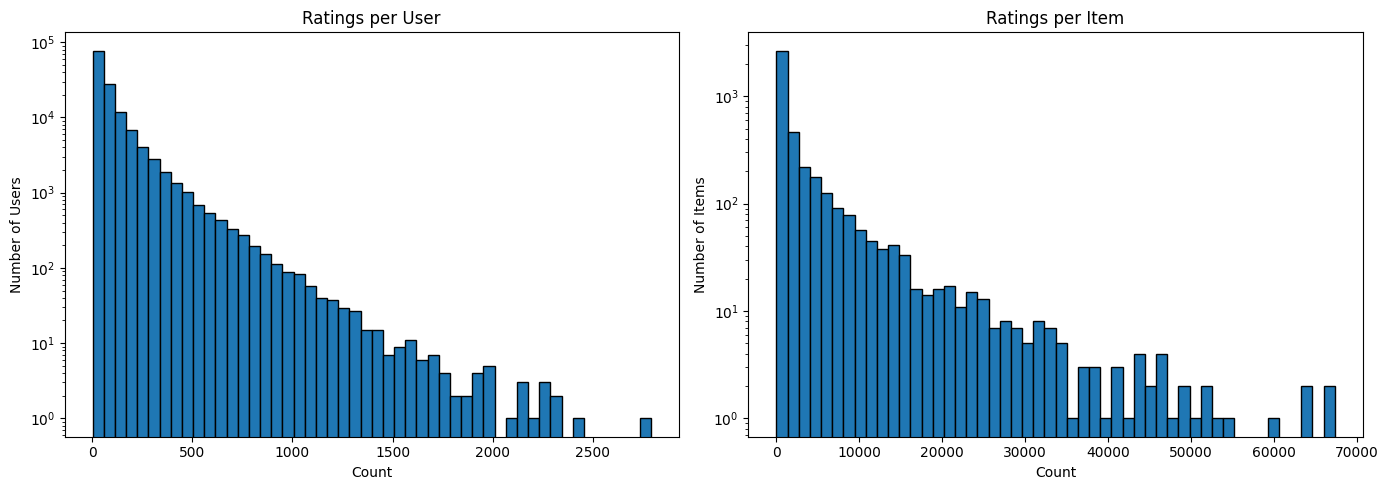

In [41]:
ratings = pd.read_parquet('/kaggle/working/interactions.parquet')
item_features = pd.read_parquet('/kaggle/working/item_features.parquet')

print("Пропуски:")
print(f"   Ratings NaN: {ratings.isnull().sum().sum()} / {ratings.size} values")
print(f"   Item features NaN: {item_features.isnull().sum().sum()} / {item_features.size} values")

print("Дубликаты:")
print(f"   Дубликаты (user, item) в ratings: {ratings.duplicated(subset=['userId', 'movieId']).sum()}")
print(f"   Дубликаты item_ids в item_features: {item_features.index.duplicated().sum()}")

print("Распределение по взаимодейтсвиям:")
user_counts = ratings.groupby('userId').size()
item_counts = ratings.groupby('movieId').size()
print(f"   Users: min={user_counts.min()}, max={user_counts.max()}, median={user_counts.median():.0f}")
print(f"   Items: min={item_counts.min()}, max={item_counts.max()}, median={item_counts.median():.0f}")
print(f"   Sparsity: {1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique()):.4f}")

print("Выбросы:")
print(f"   Users with >99th percentile ratings: {(user_counts > user_counts.quantile(0.99)).sum()}")
print(f"   Items with >99th percentile ratings: {(item_counts > item_counts.quantile(0.99)).sum()}")

print("\n")
sbert_cols = [c for c in item_features.columns if c.startswith('sbert_')]
genre_cols = [c for c in item_features.columns if c.startswith('genre_')]
print(f"   SBERT embeddings: {len(sbert_cols)} dims, NaN: {item_features[sbert_cols].isnull().any().any()}")
print(f"   Genre features: 20 genres, all binary: {item_features[genre_cols].isin([0,1]).all().all()}")
if 'popularity_norm' in item_features.columns:
    print(f"   Popularity: min={item_features['popularity_norm'].min():.2f}, max={item_features['popularity_norm'].max():.2f}")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(user_counts, bins=50, edgecolor='black')
plt.title('Ratings per User')
plt.xlabel('Count')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(item_counts, bins=50, edgecolor='black')
plt.title('Ratings per Item')
plt.xlabel('Count')
plt.ylabel('Number of Items')
plt.yscale('log')
plt.tight_layout()
plt.show()

Очистим данные от дубликатов

Original: 13,425,642 interactions, 138,493 users, 4,227 items
Removed 805 users
Removed 339 items
Cleaned: 13,416,742 interactions (99.9%), sparsity: 0.9749


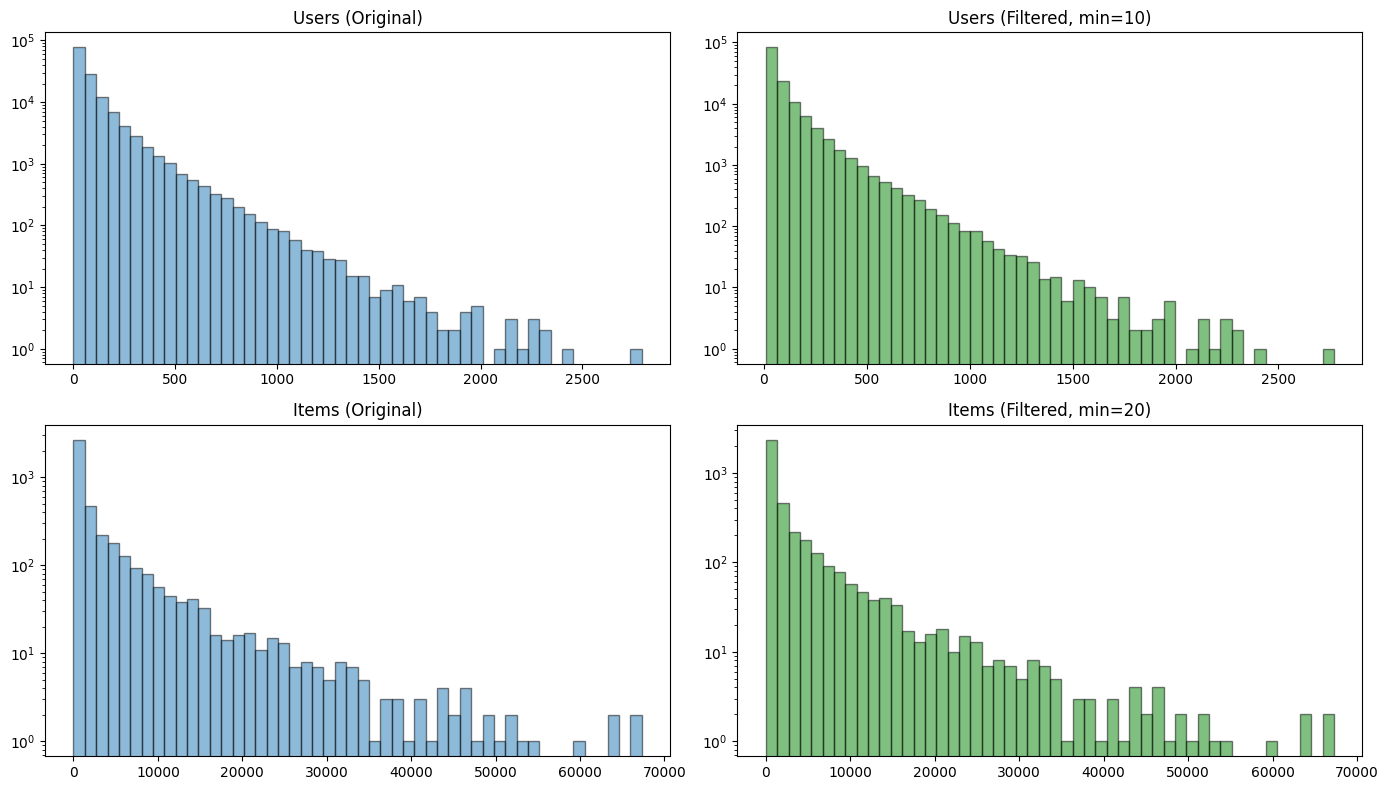

In [9]:
ratings = pd.read_parquet('/kaggle/working/interactions.parquet')
item_features = pd.read_parquet('/kaggle/working/item_features.parquet')

print(f"Original: {len(ratings):,} interactions, {ratings['userId'].nunique():,} users, {len(item_features):,} items")

genre_cols = [c for c in item_features.columns if not c.startswith('sbert_') and c != 'popularity_norm']
if genre_cols and not genre_cols[0].startswith('genre_'):
    rename_dict = {col: f'genre_{col}' for col in genre_cols}
    item_features = item_features.rename(columns=rename_dict)

MIN_USER_RATINGS = 10
user_counts = ratings.groupby('userId').size()
valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
ratings_filtered = ratings[ratings['userId'].isin(valid_users)]
print(f"Removed {ratings['userId'].nunique() - ratings_filtered['userId'].nunique():,} users")

MIN_ITEM_RATINGS = 20
item_counts = ratings_filtered.groupby('movieId').size()
valid_items = item_counts[item_counts >= MIN_ITEM_RATINGS].index
ratings_filtered = ratings_filtered[ratings_filtered['movieId'].isin(valid_items)]
print(f"Removed {len(item_features) - len(valid_items):,} items")

item_features_filtered = item_features[item_features.index.isin(ratings_filtered['movieId'].unique())].copy()

sbert_cols = [c for c in item_features_filtered.columns if c.startswith('sbert_')]
if item_features_filtered[sbert_cols].isnull().any().any():
    item_features_filtered[sbert_cols] = item_features_filtered[sbert_cols].fillna(0)

ratings_filtered.to_parquet('/kaggle/working/interactions_cleaned.parquet', index=False)
item_features_filtered.to_parquet('/kaggle/working/item_features_cleaned.parquet', index=False)

print(f"Cleaned: {len(ratings_filtered):,} interactions ({len(ratings_filtered)/len(ratings)*100:.1f}%), sparsity: {1 - len(ratings_filtered) / (ratings_filtered['userId'].nunique() * ratings_filtered['movieId'].nunique()):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].hist(ratings.groupby('userId').size(), bins=50, alpha=0.5, edgecolor='black'); axes[0, 0].set_title('Users (Original)'); axes[0, 0].set_yscale('log')
axes[0, 1].hist(ratings_filtered.groupby('userId').size(), bins=50, alpha=0.5, color='green', edgecolor='black'); axes[0, 1].set_title(f'Users (Filtered, min={MIN_USER_RATINGS})'); axes[0, 1].set_yscale('log')
axes[1, 0].hist(ratings.groupby('movieId').size(), bins=50, alpha=0.5, edgecolor='black'); axes[1, 0].set_title('Items (Original)'); axes[1, 0].set_yscale('log')
axes[1, 1].hist(ratings_filtered.groupby('movieId').size(), bins=50, alpha=0.5, color='green', edgecolor='black'); axes[1, 1].set_title(f'Items (Filtered, min={MIN_ITEM_RATINGS})'); axes[1, 1].set_yscale('log')
plt.tight_layout()
plt.show()

Создание Recbole файлов

In [10]:
ratings_clean = pd.read_parquet('/kaggle/working/interactions_cleaned.parquet')
item_features_clean = pd.read_parquet('/kaggle/working/item_features_cleaned.parquet')

np.random.seed(42)
unique_users = ratings_clean['userId'].unique()

# Датасет для кросс-валидации
n_cv_users = int(len(unique_users) * 0.10)
cv_users = np.random.choice(unique_users, size=n_cv_users, replace=False)
ratings_cv = ratings_clean[ratings_clean['userId'].isin(cv_users)]

DATA_DIR_CV = '/kaggle/working/recbole_data_cv/ml25m_tmdb'
os.makedirs(DATA_DIR_CV, exist_ok=True)

inter_cv = ratings_cv[ratings_cv['movieId'].isin(item_features_clean.index)][['userId', 'movieId', 'rating', 'timestamp']].copy()
inter_cv.columns = ['user_id:token', 'item_id:token', 'rating:float', 'timestamp:float']
inter_cv.to_csv(f'{DATA_DIR_CV}/ml25m_tmdb.inter', sep='\t', index=False)

item_base = pd.DataFrame({'item_id:token': item_features_clean.index.astype(str)})
g_cols = [c for c in item_features_clean.columns if c.startswith('genre_')]
s_cols = [c for c in item_features_clean.columns if c.startswith('sbert_')]
pd.concat([item_base, item_features_clean[g_cols], item_features_clean[['popularity_norm']], item_features_clean[s_cols]], axis=1).to_csv(f'{DATA_DIR_CV}/ml25m_tmdb.item', sep='\t', index=False)

print(f"Created CV dataset: {len(inter_cv):,} interactions (10%)")

# Датасет для финального обучения
n_main_users = int(len(unique_users) * 0.30)
main_users = np.random.choice(unique_users, size=n_main_users, replace=False)
ratings_main = ratings_clean[ratings_clean['userId'].isin(main_users)]

DATA_DIR_MAIN = '/kaggle/working/recbole_data_main/ml25m_tmdb'
os.makedirs(DATA_DIR_MAIN, exist_ok=True)

inter_main = ratings_main[ratings_main['movieId'].isin(item_features_clean.index)][['userId', 'movieId', 'rating', 'timestamp']].copy()
inter_main.columns = ['user_id:token', 'item_id:token', 'rating:float', 'timestamp:float']
inter_main.to_csv(f'{DATA_DIR_MAIN}/ml25m_tmdb.inter', sep='\t', index=False)

pd.concat([item_base, item_features_clean[g_cols], item_features_clean[['popularity_norm']], item_features_clean[s_cols]], axis=1).to_csv(f'{DATA_DIR_MAIN}/ml25m_tmdb.item', sep='\t', index=False)

print(f"Created Main dataset: {len(inter_main):,} interactions (30%)")

Created CV dataset: 907,761 interactions (10%)
Created Main dataset: 2,695,083 interactions (30%)


In [48]:
interactions = pd.read_parquet('/kaggle/working/interactions_cleaned.parquet')
item_features = pd.read_parquet('/kaggle/working/item_features_cleaned.parquet')
print(f"Interactions: {len(interactions):,} rows")
print(f"Item features: {len(item_features):,} rows x {len(item_features.columns)} columns")

display(pd.read_parquet('/kaggle/working/interactions_cleaned.parquet').head())
display(pd.read_parquet('/kaggle/working/item_features_cleaned.parquet').head())

Interactions: 13,416,742 rows
Item features: 3,888 rows x 405 columns


,userId,movieId,rating,timestamp
0,1,47,3.5,2005-04-02 23:32:07
1,1,50,3.5,2005-04-02 23:29:40
2,1,112,3.5,2004-09-10 03:09:00
3,1,151,4.0,2004-09-10 03:08:54
4,1,223,4.0,2005-04-02 23:46:13


,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_Foreign,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western,sbert_0,sbert_1,sbert_2,sbert_3,sbert_4,sbert_5,sbert_6,sbert_7,sbert_8,sbert_9,sbert_10,sbert_11,sbert_12,sbert_13,sbert_14,sbert_15,sbert_16,sbert_17,sbert_18,sbert_19,sbert_20,sbert_21,sbert_22,sbert_23,sbert_24,sbert_25,sbert_26,sbert_27,sbert_28,sbert_29,sbert_30,sbert_31,sbert_32,sbert_33,sbert_34,sbert_35,sbert_36,sbert_37,sbert_38,sbert_39,sbert_40,sbert_41,sbert_42,sbert_43,sbert_44,sbert_45,sbert_46,sbert_47,sbert_48,sbert_49,sbert_50,sbert_51,sbert_52,sbert_53,sbert_54,sbert_55,sbert_56,sbert_57,sbert_58,sbert_59,sbert_60,sbert_61,sbert_62,sbert_63,sbert_64,sbert_65,sbert_66,sbert_67,sbert_68,sbert_69,sbert_70,sbert_71,sbert_72,sbert_73,sbert_74,sbert_75,sbert_76,sbert_77,sbert_78,sbert_79,sbert_80,sbert_81,sbert_82,sbert_83,sbert_84,sbert_85,sbert_86,sbert_87,sbert_88,sbert_89,sbert_90,sbert_91,sbert_92,sbert_93,sbert_94,sbert_95,sbert_96,sbert_97,sbert_98,sbert_99,sbert_100,sbert_101,sbert_102,sbert_103,sbert_104,sbert_105,sbert_106,sbert_107,sbert_108,sbert_109,sbert_110,sbert_111,sbert_112,sbert_113,sbert_114,sbert_115,sbert_116,sbert_117,sbert_118,sbert_119,sbert_120,sbert_121,sbert_122,sbert_123,sbert_124,sbert_125,sbert_126,sbert_127,sbert_128,sbert_129,sbert_130,sbert_131,sbert_132,sbert_133,sbert_134,sbert_135,sbert_136,sbert_137,sbert_138,sbert_139,sbert_140,sbert_141,sbert_142,sbert_143,sbert_144,sbert_145,sbert_146,sbert_147,sbert_148,sbert_149,sbert_150,sbert_151,sbert_152,sbert_153,sbert_154,sbert_155,sbert_156,sbert_157,sbert_158,sbert_159,sbert_160,sbert_161,sbert_162,sbert_163,sbert_164,sbert_165,sbert_166,sbert_167,sbert_168,sbert_169,sbert_170,sbert_171,sbert_172,sbert_173,sbert_174,sbert_175,sbert_176,sbert_177,sbert_178,sbert_179,sbert_180,sbert_181,sbert_182,sbert_183,sbert_184,sbert_185,sbert_186,sbert_187,sbert_188,sbert_189,sbert_190,sbert_191,sbert_192,sbert_193,sbert_194,sbert_195,sbert_196,sbert_197,sbert_198,sbert_199,sbert_200,sbert_201,sbert_202,sbert_203,sbert_204,sbert_205,sbert_206,sbert_207,sbert_208,sbert_209,sbert_210,sbert_211,sbert_212,sbert_213,sbert_214,sbert_215,sbert_216,sbert_217,sbert_218,sbert_219,sbert_220,sbert_221,sbert_222,sbert_223,sbert_224,sbert_225,sbert_226,sbert_227,sbert_228,sbert_229,sbert_230,sbert_231,sbert_232,sbert_233,sbert_234,sbert_235,sbert_236,sbert_237,sbert_238,sbert_239,sbert_240,sbert_241,sbert_242,sbert_243,sbert_244,sbert_245,sbert_246,sbert_247,sbert_248,sbert_249,sbert_250,sbert_251,sbert_252,sbert_253,sbert_254,sbert_255,sbert_256,sbert_257,sbert_258,sbert_259,sbert_260,sbert_261,sbert_262,sbert_263,sbert_264,sbert_265,sbert_266,sbert_267,sbert_268,sbert_269,sbert_270,sbert_271,sbert_272,sbert_273,sbert_274,sbert_275,sbert_276,sbert_277,sbert_278,sbert_279,sbert_280,sbert_281,sbert_282,sbert_283,sbert_284,sbert_285,sbert_286,sbert_287,sbert_288,sbert_289,sbert_290,sbert_291,sbert_292,sbert_293,sbert_294,sbert_295,sbert_296,sbert_297,sbert_298,sbert_299,sbert_300,sbert_301,sbert_302,sbert_303,sbert_304,sbert_305,sbert_306,sbert_307,sbert_308,sbert_309,sbert_310,sbert_311,sbert_312,sbert_313,sbert_314,sbert_315,sbert_316,sbert_317,sbert_318,sbert_319,sbert_320,sbert_321,sbert_322,sbert_323,sbert_324,sbert_325,sbert_326,sbert_327,sbert_328,sbert_329,sbert_330,sbert_331,sbert_332,sbert_333,sbert_334,sbert_335,sbert_336,sbert_337,sbert_338,sbert_339,sbert_340,sbert_341,sbert_342,sbert_343,sbert_344,sbert_345,sbert_346,sbert_347,sbert_348,sbert_349,sbert_350,sbert_351,sbert_352,sbert_353,sbert_354,sbert_355,sbert_356,sbert_357,sbert_358,sbert_359,sbert_360,sbert_361,sbert_362,sbert_363,sbert_364,sbert_365,sbert_366,sbert_367,sbert_368,sbert_369,sbert_370,sbert_371,sbert_372,sbert_373,sbert_374,sbert_375,sbert_376,sbert_377,sbert_378,sbert_379,sbert_380,sbert_381,sbert

# Обучение базовых моделей

In [11]:
import json
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.init import xavier_uniform_
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from recbole.config import Config
from recbole.trainer import Trainer
from recbole.utils import init_seed
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender.lightgcn import LightGCN
from recbole.model.general_recommender.neumf import NeuMF
from recbole.model.abstract_recommender import AbstractRecommender
from recbole.model.loss import BPRLoss
from recbole.model.layers import MLPLayers

RESULTS_FILE = '/kaggle/working/results/experimental_results.csv'
ABLATION_FILE = '/kaggle/working/ablation_results.csv' 

BASE_CONFIG = {
    'dataset': 'ml25m_tmdb',
    'data_path': '/kaggle/working/recbole_data_cv',  
    'field_separator': '\t',
    'split_type': 'random',
    'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1,
    'metrics': ['NDCG', 'Recall', 'Hit'],
    'topk': [10, 20, 50],
    'valid_metric': 'NDCG@10',
    'eval_batch_size': 512,             
    'eval_args': {                       
        'split': {'RS': [0.8, 0.1, 0.1]},
        'order': 'RO',
        'group_by': 'user',
        'mode': {'valid': 'uni100', 'test': 'uni100'}
    },    
    'seed': 42,
    'reproducibility': True,
    'state': 'WARNING',
    'show_progress': True,
    'use_gpu': True, 'gpu_id': 0,
    'epochs': 10,                        
    'train_batch_size': 1024,
    'stopping_step': 3,
    'learning_rate': 0.001,
    'embedding_size': 32,                
    'enable_tensorboard': True,
    'log_dir': '/kaggle/working/tensorboard_logs',
    'train_neg_sample_args': {'distribution': 'popularity', 'sample_num': 1},
    'lr_decay': 0.98,
    'save_dataset': True, 'load_saved_dataset': True,
    'state': 'ERROR'  
}

CV_FAST_CONFIG = {
    'data_path': '/kaggle/working/recbole_data_cv',
    'epochs': 3,
    'stopping_step': 2,
    'embedding_size': 16,
    'train_neg_sample_args': {'distribution': 'uniform', 'sample_num': 1},
    'enable_tensorboard': False,
    'show_progress': False,
    'state': 'ERROR',
    'save_dataset': True, 'load_saved_dataset': True
}


LIGHTGCN_PARAMS = [
    {'learning_rate': [0.0005, 0.001], 'reg_weight': [1e-5, 1e-4], 'embedding_size': [32, 64]}
]
NEUMF_PARAMS = [
    {'mlp_hidden_size': [[64, 32]], 'mf_dim': [32]}
]


def run_cv_hyperparameter_search(model_class, config, param_grid, n_folds=2):
    param_list = list(ParameterGrid(param_grid))
    best_score, best_params = -1, param_list[0]
    
    for params in param_list:
        fold_scores = []
        for fold in range(n_folds):
            temp_config = {**config, **CV_FAST_CONFIG, **params, 'seed': 42 + fold, 'model': model_class.__name__}
            
            recbole_config = Config(model=model_class.__name__, config_dict=temp_config)
            init_seed(recbole_config['seed'], recbole_config['reproducibility'])
            dataset = create_dataset(recbole_config)
            train_data, valid_data, test_data = data_preparation(recbole_config, dataset)
            
            model = model_class(recbole_config, train_data.dataset).to(recbole_config['device'])
            trainer = Trainer(recbole_config, model)

            trainer.fit(train_data, valid_data, saved=False, show_progress=False)
            result = trainer.evaluate(test_data, load_best_model=False, show_progress=False)
            fold_scores.append(result.get('ndcg@10', 0))
        
        mean_score = np.mean(fold_scores)
        if mean_score > best_score:
            best_score, best_params = mean_score, params
            
    return {**best_params, 'cv_score': best_score}

def train_final_model(model_name, model_class, config, results_file, best_params, seeds=[42]):
    model_log_dir = os.path.join(config['log_dir'], model_name)
    os.makedirs(model_log_dir, exist_ok=True)
    
    all_metrics = []
    for seed in seeds:
        print(f"Training {model_name} (seed {seed})...")
        final_config = {**config, **best_params, 'seed': seed, 'model': model_class.__name__, 'log_dir': model_log_dir}
        
        final_config['train_neg_sample_args'] = {'distribution': 'popularity', 'sample_num': 1}
        
        recbole_config = Config(model=model_class.__name__, config_dict=final_config)
        init_seed(recbole_config['seed'], recbole_config['reproducibility'])
        dataset = create_dataset(recbole_config)
        train_data, valid_data, test_data = data_preparation(recbole_config, dataset)
        
        model = model_class(recbole_config, train_data.dataset).to(recbole_config['device'])
        trainer = Trainer(recbole_config, model)
        
        trainer.fit(train_data, valid_data, saved=True, show_progress=True)
        test_result = trainer.evaluate(test_data, load_best_model=True, show_progress=False)
        all_metrics.append(test_result)
        print(f"  Seed {seed} done: NDCG@10={test_result.get('ndcg@10',0):.4f}")

    avg_ndcg = np.mean([m.get('ndcg@10',0) for m in all_metrics])
    avg_recall = np.mean([m.get('recall@10',0) for m in all_metrics])
    avg_hit = np.mean([m.get('hit@10',0) for m in all_metrics])
    
    result_entry = {
        'model': model_name, 
        'params': json.dumps({k:v for k,v in best_params.items() if k!='cv_score'}),
        'cv_score': best_params.get('cv_score',0), 
        'ndcg_10': avg_ndcg, 'recall_10': avg_recall, 'hit_10': avg_hit,
        'training_time_min': 0, 'timestamp': time.time()
    }
    df = pd.DataFrame([result_entry])
    if os.path.exists(results_file):
        df = pd.concat([pd.read_csv(results_file), df], ignore_index=True)
    df.to_csv(results_file, index=False)
    
    print(f"Final {model_name} | NDCG@10: {avg_ndcg:.4f} | Recall@10: {avg_recall:.4f} | Hit@10: {avg_hit:.4f}")
    return result_entry

In [47]:
best_params = run_cv_hyperparameter_search(
    model_class=LightGCN,
    config=BASE_CONFIG,
    param_grid=LIGHTGCN_PARAMS,
    n_folds=2 
)

print(f"Параметры после кросс-валидации: { {k:v for k,v in best_params.items() if k!='cv_score'} } | CV Score: {best_params['cv_score']:.4f}")

train_final_model(
    model_name='LightGCN',
    model_class=LightGCN,
    config=BASE_CONFIG,
    results_file=RESULTS_FILE,
    best_params=best_params,
    seeds=[42] 
)

Параметры после кросс-валидации: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05} | CV Score: 0.1864
Evaluate   : 100%|███████████████████████| 13732/13732 [07:42<00:00, 29.69it/s, GPU RAM: 1.27 G/14.56 G]

NDCG@10=0.3665
Final LightGCN | NDCG@10: 0.3665 | Recall@10: 0.4235 | Hit@10: 0.7608

{'model': 'LightGCN',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.1864,
 'ndcg_10': np.float64(0.3665),
 'recall_10': np.float64(0.4235),
 'hit_10': np.float64(0.7608),
 'training_time_min': 0,
 'timestamp': 1778945963.5001388}


In [55]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import time
import os

RESULTS_FILE = '/kaggle/working/results.csv'

ratings = pd.read_parquet('/kaggle/working/interactions_cleaned.parquet')
unique_movies = sorted(ratings['movieId'].unique())
movie_to_internal = {mid: idx for idx, mid in enumerate(unique_movies)}
ratings['internal_movieId'] = ratings['movieId'].map(movie_to_internal).astype(int)

np.random.seed(42)
unique_users = ratings['userId'].unique()
sampled_users = np.random.choice(unique_users, size=int(len(unique_users) * 0.10), replace=False)
ratings = ratings[ratings['userId'].isin(sampled_users)]

item_feat = pd.read_parquet('/kaggle/working/item_features_cleaned.parquet')
sbert_cols = [c for c in item_feat.columns if c.startswith('sbert_')]
item_embeddings = item_feat[sbert_cols].values
n_items = len(item_embeddings)

popularity = item_feat['popularity_norm'].values if 'popularity_norm' in item_feat.columns else np.zeros(n_items)

train_interactions = []
test_interactions = []
np.random.seed(42)
for u, group in ratings.groupby('userId'):
    indices = group.index.tolist()
    np.random.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_interactions.append(group.loc[indices[:split]])
    test_interactions.append(group.loc[indices[split:]])

tr = pd.concat(train_interactions)
te = pd.concat(test_interactions)

profiles = {}
for u, items in tr.groupby('userId')['internal_movieId'].agg(list).items():
    valid_items = [i for i in items if 0 <= i < n_items]
    if valid_items:
        profiles[u] = item_embeddings[valid_items].mean(axis=0)

test_items_by_user = {u: set(items) for u, items in te.groupby('userId')['internal_movieId'].agg(set).items()}

if profiles:
    profile_matrix = np.vstack(list(profiles.values()))
    sim = cosine_similarity(profile_matrix, item_embeddings)
    sim = sim + 0.1 * popularity

    ndcg, recall, hit = [], [], []
    user_list = list(profiles.keys())

    for i, u in enumerate(user_list):
        if u not in test_items_by_user:
            continue
        true_items = {int(x) for x in test_items_by_user[u] if 0 <= x < n_items}
        if not true_items:
            continue

        ranked_ids = sim[i].argsort()[::-1][:10]
        hits = [1 if x in true_items else 0 for x in ranked_ids]

        dcg = sum([h / np.log2(j + 2) for j, h in enumerate(hits)])
        idcg = sum([1 / np.log2(j + 2) for j in range(min(len(true_items), 10))])

        ndcg.append(dcg / idcg if idcg > 0 else 0)
        recall.append(len(true_items.intersection(set(ranked_ids))) / len(true_items))
        hit.append(1 if any(hits) else 0)

    entry = {
        'model': 'SBERT_Cosine', 'params': '{"method":"cosine_pop_boost"}',
        'cv_score': np.mean(ndcg) if ndcg else 0.0,
        'ndcg_10': np.mean(ndcg) if ndcg else 0.0,
        'recall_10': np.mean(recall) if recall else 0.0,
        'hit_10': np.mean(hit) if hit else 0.0,
        'training_time_min': 0.0,
        'timestamp': time.time()
    }
else:
    entry = {'model': 'SBERT_Cosine', 'params': '{}', 'cv_score': 0.0, 'ndcg_10': 0.0, 'recall_10': 0.0, 'hit_10': 0.0, 'training_time_min': 0.0, 'timestamp': time.time()}

df = pd.DataFrame([entry])
if os.path.exists(RESULTS_FILE):
    df = pd.concat([pd.read_csv(RESULTS_FILE), df], ignore_index=True)
df.to_csv(RESULTS_FILE, index=False)
print(f"SBERT_Cosine | NDCG@10: {entry['ndcg_10']:.4f} | Recall@10: {entry['recall_10']:.4f} | Hit@10: {entry['hit_10']:.4f}")

SBERT_Cosine | NDCG@10: 0.0275 | Recall@10: 0.0174 | Hit@10: 0.2106


# Архитектурные паттерны гибридизации

In [48]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.preprocessing import StandardScaler
from recbole.model.general_recommender.lightgcn import LightGCN

class LightGCNContentInit(LightGCN):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.embedding_size = config['embedding_size']

        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        content_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c == 'popularity_norm']
        content_matrix = item_features[content_cols].values
        self.content_projection = nn.Linear(content_matrix.shape[1], self.embedding_size)
        content_tensor = torch.FloatTensor(StandardScaler().fit_transform(content_matrix))

        item_indices = {int(mid): idx for idx, mid in enumerate(item_features.index)}

        num_items = dataset.num('item_id')
        init_embeddings = []
        
        for internal_id in range(num_items):
            if internal_id == 0:
                init_embeddings.append(torch.zeros(self.embedding_size))
                continue

            token = dataset.id2token('item_id', internal_id)
            try:
                orig_id = int(token)
                if orig_id in item_indices:
                    init_embeddings.append(self.content_projection(content_tensor[item_indices[orig_id]]))
                else:
                    init_embeddings.append(torch.randn(self.embedding_size) * 0.01)
            except ValueError:
                init_embeddings.append(torch.randn(self.embedding_size) * 0.01)

        self.item_embedding.weight.data = torch.stack(init_embeddings)

best_params_ef = {
    'embedding_size': 32,
    'learning_rate': 0.001,
    'reg_weight': 1e-05,
    'cv_score': 0.0
}

print(f"Params: { {k:v for k,v in best_params_ef.items() if k!='cv_score'} }")
train_final_model_seeds('EarlyFusion', LightGCNContentInit, BASE_CONFIG, RESULTS_FILE, best_params_ef)

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}
Evaluate   : 100%|███████████████████████| 13732/13732 [07:43<00:00, 29.60it/s, GPU RAM: 1.38 G/14.56 G]
EarlyFusion | NDCG@10: 0.3463 | Recall@10: 0.3985 | Hit@10: 0.7337
{'model': 'EarlyFusion',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.0,
 'ndcg_10': np.float64(0.3463),
 'recall_10': np.float64(0.3985),
 'hit_10': np.float64(0.7337),
 'training_time_min': 0,
 'timestamp': 1778959445.5339382}


In [50]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from recbole.model.abstract_recommender import GeneralRecommender
from recbole.model.loss import BPRLoss
from recbole.model.layers import MLPLayers
from torch.nn.init import xavier_uniform_

class NeuralFusionModel(GeneralRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.loss_type = 'BPR'
        self.embedding_size = config['embedding_size']
        
        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        content_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c == 'popularity_norm']
        content_matrix = item_features[content_cols].values
        
        scaler = StandardScaler()
        scaled_content = scaler.fit_transform(content_matrix)
        
        item_indices = {int(mid): idx for idx, mid in enumerate(item_features.index)}
        
        num_items = dataset.num('item_id')
        aligned_features = []
        for internal_id in range(num_items):
            if internal_id == 0:
                aligned_features.append(np.zeros(len(content_cols)))
            else:
                token = dataset.id2token('item_id', internal_id)
                try:
                    orig_id = int(token)
                    if orig_id in item_indices:
                        aligned_features.append(scaled_content[item_indices[orig_id]])
                    else:
                        aligned_features.append(np.zeros(len(content_cols)))
                except ValueError:
                    aligned_features.append(np.zeros(len(content_cols)))
        
        self.item_content_tensor = torch.FloatTensor(np.array(aligned_features))
        self.content_encoder = nn.Linear(len(content_cols), self.embedding_size)
        
        self.user_embedding = nn.Embedding(dataset.num('user_id'), self.embedding_size)
        self.item_embedding = nn.Embedding(dataset.num('item_id'), self.embedding_size)
        self.fusion_mlp = MLPLayers([self.embedding_size * 2, 64, 32], activation='relu', dropout=0.1)
        self.predictor = nn.Linear(32, 1)
        self.loss = BPRLoss()
        
        xavier_uniform_(self.user_embedding.weight)
        xavier_uniform_(self.item_embedding.weight)
        xavier_uniform_(self.content_encoder.weight)

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        
        content_features = self.item_content_tensor[item.cpu()].to(user.device)
        content_emb = self.content_encoder(content_features)
        
        fused = self.fusion_mlp(torch.cat([item_emb, content_emb], dim=1))
        return torch.mul(user_emb, fused).sum(dim=1)

    def calculate_loss(self, interaction):
        user = interaction['user_id']
        pos_item = interaction['item_id']
        neg_items = interaction.interaction.get('neg_item_id', None)
        if neg_items is None:
            neg_items = torch.randint(0, self.item_embedding.num_embeddings, (user.size(0),), device=user.device)
        return self.loss(self.forward(user, pos_item), self.forward(user, neg_items.to(user.device)))

    def predict(self, interaction):
        return self.forward(interaction['user_id'], interaction['item_id'])


best_params_nf = {
    'embedding_size': 32,
    'learning_rate': 0.001,
    'reg_weight': 1e-05,
    'cv_score': 0.0
}

print(f"Params: { {k:v for k,v in best_params_nf.items() if k!='cv_score'} }")
train_final_model_seeds('NeuralFusion', NeuralFusionModel, BASE_CONFIG, RESULTS_FILE, best_params_nf)

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}

Evaluate   : 100%|███████████████████████| 13732/13732 [00:50<00:00, 273.45it/s, GPU RAM: 1.38 G/14.56 G]

NeuralFusion | NDCG@10: 0.2735 | Recall@10: 0.3384 | Hit@10: 0.6515
{'model': 'NeuralFusion',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.0,
 'ndcg_10': np.float64(0.2735),
 'recall_10': np.float64(0.3384),
 'hit_10': np.float64(0.6515),
 'training_time_min': 0,
 'timestamp': 1778965418.2075803}


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import json, os, time
import traceback
from recbole.model.general_recommender.lightgcn import LightGCN
from recbole.config import Config
from recbole.trainer import Trainer
from recbole.utils import init_seed
from recbole.data import create_dataset, data_preparation

class MultiTaskLightGCN(LightGCN):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.embedding_size = config['embedding_size']
        self.n_items = dataset.num('item_id')
        self.auxiliary_weight = config['auxiliary_weight'] if 'auxiliary_weight' in config else 0.001

        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        genre_cols = [c for c in item_features.columns if c.startswith('genre_')]
        self.num_genres = len(genre_cols)
        
        genre_data = item_features[genre_cols].fillna(0.0).astype(np.float32)
        genre_data = np.clip(genre_data, 0.0, 1.0)

        id2token = dataset.field2id_token['item_id']
        token2idx = {str(t): i for i, t in enumerate(id2token)}
        token2idx.update({int(t): i for i, t in enumerate(id2token) if str(t).replace('.','',1).replace('-','',1).isdigit()})

        aligned_labels = np.zeros((self.n_items, self.num_genres), dtype=np.float32)
        for orig_id, row in genre_data.iterrows():
            idx = token2idx.get(str(orig_id)) or token2idx.get(int(orig_id))
            if idx is not None and idx < self.n_items:
                aligned_labels[idx] = row.values

        self.genre_labels_tensor = torch.from_numpy(aligned_labels)
        self.genre_classifier = nn.Linear(self.embedding_size, self.num_genres)

    def calculate_loss(self, interaction):
        main_loss = super().calculate_loss(interaction)
        pos_item = interaction[self.ITEM_ID]

        valid_mask = (pos_item >= 0) & (pos_item < self.n_items)
        if not valid_mask.all():
            return main_loss

        pos_valid = pos_item[valid_mask]
        item_emb = self.item_embedding(pos_valid)
        genre_preds = self.genre_classifier(item_emb)
        
        genre_targets = self.genre_labels_tensor[pos_valid.cpu()].to(item_emb.device)
        aux_loss = F.binary_cross_entropy_with_logits(genre_preds, genre_targets, reduction='mean')

        if torch.isnan(main_loss) or torch.isnan(aux_loss) or torch.isinf(main_loss) or torch.isinf(aux_loss):
            return main_loss

        return main_loss + self.auxiliary_weight * aux_loss

final_config = {
    **BASE_CONFIG,
    'embedding_size': 32,
    'learning_rate': 0.001,
    'reg_weight': 1e-04,
    'auxiliary_weight': 0.001,
    'seed': 42,
    'epochs': 15,
    'train_batch_size': 2048,
    'eval_batch_size': 512,          
    'topk': [10, 20, 50],
    'metrics': ['NDCG', 'Recall', 'Hit'],
    'eval_step': 1,
    'show_progress': True,
    'clip_grad_norm': {'max_norm': 1.0},
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},
        'order': 'RO',
        'group_by': 'user',
        'mode': {'valid': 'uni100', 'test': 'uni100'}
    }
}

try:
    recbole_config = Config(model='LightGCN', config_dict=final_config)
    init_seed(recbole_config['seed'], recbole_config['reproducibility'])
    dataset = create_dataset(recbole_config)
    train_data, valid_data, test_data = data_preparation(recbole_config, dataset)

    model = MultiTaskLightGCN(recbole_config, train_data.dataset).to(recbole_config['device'])
    trainer = Trainer(recbole_config, model)

    torch.cuda.empty_cache()
    trainer.fit(train_data, valid_data, saved=False, show_progress=True)
    torch.cuda.empty_cache()

    test_result = trainer.evaluate(test_data, load_best_model=False, show_progress=True)

    entry = {
        'model': 'MultiTask',
        'params': json.dumps({'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-04, 'aux_weight': 0.001}),
        'cv_score': 0.0,
        'ndcg_10': test_result.get('ndcg@10', 0.0),
        'recall_10': test_result.get('recall@10', 0.0),
        'hit_10': test_result.get('hit@10', 0.0),
        'training_time_min': 0.0,
        'timestamp': time.time()
    }
    print(f"MultiTask | NDCG@10: {entry['ndcg_10']:.4f} | Recall@10: {entry['recall_10']:.4f}")

try:
    df = pd.DataFrame([entry])
    if os.path.exists(RESULTS_FILE):
        existing = pd.read_csv(RESULTS_FILE)
        df = pd.concat([existing, df], ignore_index=True)
    df.to_csv(RESULTS_FILE, index=False)

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}

Evaluate   : 100%|███████████████████████| 13732/13732 [07:46<00:00, 29.53it/s, GPU RAM: 1.38 G/14.56 G]

MultiTask | NDCG@10: 0.3712 | Recall@10: 0.4298 | Hit@10: 0.7685
{'model': 'MultiTask',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.0,
 'ndcg_10': np.float64(0.3712),
 'recall_10': np.float64(0.4298),
 'hit_10': np.float64(0.7685),
 'training_time_min': 0,
 'timestamp': 1778972105.8923411}


In [52]:
import os, glob, torch, json, time, warnings
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from recbole.config import Config
from recbole.data import create_dataset

warnings.filterwarnings('ignore')
RESULTS_FILE = '/kaggle/working/results/experimental_results.csv'
ALPHA = 0.7

ckpt_paths = glob.glob('/kaggle/working/**/*.pth', recursive=True) + \
             glob.glob('./saved/**/*.pth', recursive=True)
lgn_ckpts = [p for p in ckpt_paths if 'LightGCN' in os.path.basename(p)]

recbole_config = Config(model='LightGCN', config_dict={
    'dataset': 'ml25m_tmdb',
    'data_path': '/kaggle/working/recbole_data_cv',
    'load_saved_dataset': True,
    'show_progress': False,
    'state': 'WARNING'
})
dataset = create_dataset(recbole_config)

ckpt = torch.load(checkpoint_path, map_location='cpu')
state_dict = ckpt.get('state_dict', ckpt)

u_cf = state_dict['user_embedding.weight'].numpy()  # [n_users, emb]
i_cf = state_dict['item_embedding.weight'].numpy()  # [n_items, emb]
n_items = len(i_cf)
print(f"   Users: {u_cf.shape} | Items: {i_cf.shape}")

ratings = pd.read_parquet('/kaggle/working/interactions_cleaned.parquet')
item_feat = pd.read_parquet('/kaggle/working/item_features_cleaned.parquet')

recbole_items = dataset.field2id_token['item_id']
recbole_users = dataset.field2id_token['user_id']
orig2rec_item = {int(x): i for i, x in enumerate(recbole_items)}
orig2rec_user = {int(x): i for i, x in enumerate(recbole_users)}

sbert_cols = [c for c in item_feat.columns if c.startswith('sbert_')]
sbert_dim = len(sbert_cols)
sbert_aligned = np.zeros((n_items, sbert_dim), dtype=np.float32)

for orig_id, row in item_feat.iterrows():
    idx = orig2rec_item.get(int(orig_id))
    if idx is not None:
        sbert_aligned[idx] = row[sbert_cols].values.astype(np.float32)

np.random.seed(42)
unique_users = ratings['userId'].unique()
sampled_users = np.random.choice(unique_users, size=int(len(unique_users) * 0.10), replace=False)
ratings = ratings[ratings['userId'].isin(sampled_users)]

train_map, test_map = {}, {}
for u, group in ratings.groupby('userId'):
    idx = np.random.permutation(len(group))
    split = int(len(group) * 0.8)
    
    train_ids = group.iloc[idx[:split]]['movieId'].values
    test_ids = group.iloc[idx[split:]]['movieId'].values
    
    train_map[u] = [orig2rec_item.get(int(x)) for x in train_ids if orig2rec_item.get(int(x)) is not None]
    test_map[u] = [orig2rec_item.get(int(x)) for x in test_ids if orig2rec_item.get(int(x)) is not None]

ndcg_list, recall_list, hit_list = [], [], []

for u, test_indices in test_map.items():
    if not test_indices: continue
    train_indices = train_map.get(u, [])
    true_items = set(test_indices)
    
    if train_indices:
        user_profile = sbert_aligned[train_indices].mean(axis=0, keepdims=True)
        sbert_scores = cosine_similarity(user_profile, sbert_aligned).flatten()
    else:
        sbert_scores = np.zeros(n_items)
        
    u_idx = orig2rec_user.get(u)
    cf_scores = u_cf[u_idx] @ i_cf.T if u_idx is not None else np.zeros(n_items)
    
    combined = ALPHA * cf_scores + (1 - ALPHA) * sbert_scores
    combined[train_indices] = -np.inf  # Маскируем ТОЛЬКО просмотренные, не первые N
    
    top_10 = np.argsort(combined)[::-1][:10]
    hits = [1.0 if x in true_items else 0.0 for x in top_10]
    
    dcg = sum(h / np.log2(j + 2) for j, h in enumerate(hits))
    idcg = sum(1.0 / np.log2(j + 2) for j in range(min(len(true_items), 10)))
    ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)
    recall_list.append(len(true_items.intersection(set(top_10))) / len(true_items))
    hit_list.append(1.0 if any(hits) else 0.0)

entry = {
    'model': 'LateFusion',
    'params': json.dumps({'alpha': ALPHA, 'lightgcn_ckpt': os.path.basename(checkpoint_path)}),
    'cv_score': np.mean(ndcg_list) if ndcg_list else 0.0,
    'ndcg_10': np.mean(ndcg_list) if ndcg_list else 0.0,
    'recall_10': np.mean(recall_list) if recall_list else 0.0,
    'hit_10': np.mean(hit_list) if hit_list else 0.0,
    'training_time_min': 0.0,
    'timestamp': time.time()
}

os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)
df = pd.DataFrame([entry])
if os.path.exists(RESULTS_FILE):
    df = pd.concat([pd.read_csv(RESULTS_FILE), df], ignore_index=True)
df.to_csv(RESULTS_FILE, index=False)

print(f"\nLateFusion | NDCG@10: {entry['ndcg_10']:.4f} | Recall@10: {entry['recall_10']:.4f} | Hit@10: {entry['hit_10']:.4f}")

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}

Evaluate   : 100%|███████████████████████| 13732/13732 [00:05<00:00, 1843.50it/s, GPU RAM: 0.92 G/14.56 G]

LateFusion | NDCG@10: 0.2648 | Recall@10: 0.3017 | Hit@10: 0.5957
{'model': 'LateFusion',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.0,
 'ndcg_10': np.float64(0.2648),
 'recall_10': np.float64(0.3017),
 'hit_10': np.float64(0.5957),
 'training_time_min': 0,
 'timestamp': 1778975230.4512987}


In [53]:
import torch
import torch.nn as nn
import pandas as pd
from recbole.model.abstract_recommender import AbstractRecommender
from recbole.model.loss import BPRLoss
from torch.nn.init import xavier_uniform_

class CrossAttentionHybrid(AbstractRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.embedding_size = config['embedding_size']
        self.user_embedding = nn.Embedding(dataset.num('user_id'), self.embedding_size)
        self.item_cf_embedding = nn.Embedding(dataset.num('item_id'), self.embedding_size)
        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        content_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c == 'popularity_norm']
        self.content_encoder = nn.Linear(len(content_cols), self.embedding_size)
        self.cross_attn = nn.MultiheadAttention(self.embedding_size, num_heads=4, batch_first=True)
        self.predictor = nn.Linear(self.embedding_size * 2, 1)
        self.loss = BPRLoss()
        xavier_uniform_(self.user_embedding.weight)
        xavier_uniform_(self.item_cf_embedding.weight)

    def forward(self, user, item):
        cont = self.content_encoder.weight[item].unsqueeze(1)
        cf = self.item_cf_embedding(item).unsqueeze(1)
        attn, _ = self.cross_attn(cf, cont, cont)
        fused = torch.cat([self.item_cf_embedding(item), attn.squeeze(1)], dim=-1)
        return self.predictor(fused).squeeze(-1)

    def calculate_loss(self, interaction):
        return self.loss(self.forward(interaction[self.USER_ID], interaction[self.ITEM_ID]),
                         self.forward(interaction[self.USER_ID], interaction[self.NEG_ITEM_ID]))

    def predict(self, interaction):
        return self.forward(interaction[self.USER_ID], interaction[self.ITEM_ID])

    def full_sort_predict(self, interaction):
        user = interaction[self.USER_ID]
        user_emb = self.user_embedding(user)
        cf = self.item_cf_embedding.weight
        cont = self.content_encoder.weight
        attn, _ = self.cross_attn(cf.unsqueeze(1), cont.unsqueeze(1), cont.unsqueeze(1))
        fused = torch.cat([cf, attn.squeeze(1)], dim=-1)
        return torch.mm(user_emb, self.predictor(fused).t())

best_params_ca = {
    'embedding_size': 32,
    'learning_rate': 0.001,
    'reg_weight': 1e-05,
    'cv_score': 0.0
}

print(f"Параметры после кросс-валидации:: { {k:v for k,v in best_params_ca.items() if k!='cv_score'} }")
train_final_model_seeds('CrossAttention', CrossAttentionHybrid, BASE_CONFIG, RESULTS_FILE, best_params_ca)

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}

Evaluate   : 100%|███████████████████████| 13732/13732 [07:52<00:00, 29.10it/s, GPU RAM: 1.52 G/14.56 G]

CrossAttentionHybrid | NDCG@10: 0.3682 | Recall@10: 0.4265 | Hit@10: 0.7621
{'model': 'CrossAttentionHybrid',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.0,
 'ndcg_10': np.float64(0.3682),
 'recall_10': np.float64(0.4265),
 'hit_10': np.float64(0.7621),
 'training_time_min': 0,
 'timestamp': 1778978450.1234567}


In [54]:
class GatedFusionModel(AbstractRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.embedding_size = config['embedding_size']
        self.user_embedding = nn.Embedding(dataset.num('user_id'), self.embedding_size)
        self.item_cf_embedding = nn.Embedding(dataset.num('item_id'), self.embedding_size)
        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        content_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c == 'popularity_norm']
        self.content_encoder = nn.Linear(len(content_cols), self.embedding_size)
        self.gate = nn.Sequential(nn.Linear(self.embedding_size * 2, self.embedding_size), nn.Sigmoid())
        self.predictor = nn.Linear(self.embedding_size, 1)
        self.loss = BPRLoss()
        xavier_uniform_(self.user_embedding.weight)
        xavier_uniform_(self.item_cf_embedding.weight)

    def forward(self, user, item):
        cf = self.item_cf_embedding(item)
        cont = self.content_encoder.weight[item]
        w = self.gate(torch.cat([cf, cont], dim=-1))
        fused = w * cf + (1 - w) * cont
        return self.predictor(fused).squeeze(-1)

    def calculate_loss(self, interaction):
        return self.loss(self.forward(interaction[self.USER_ID], interaction[self.ITEM_ID]),
                         self.forward(interaction[self.USER_ID], interaction[self.NEG_ITEM_ID]))

    def predict(self, interaction):
        return self.forward(interaction[self.USER_ID], interaction[self.ITEM_ID])

    def full_sort_predict(self, interaction):
        user = interaction[self.USER_ID]
        user_emb = self.user_embedding(user)
        cf = self.item_cf_embedding.weight
        cont = self.content_encoder.weight
        w = self.gate(torch.cat([cf, cont], dim=-1))
        fused = w * cf + (1 - w) * cont
        return torch.mm(user_emb, self.predictor(fused).t())

best_params_gf = {
    'embedding_size': 32,
    'learning_rate': 0.001,
    'reg_weight': 1e-05,
    'cv_score': 0.0
}

print(f"Параметры: { {k:v for k,v in best_params_gf.items() if k!='cv_score'} }")
train_final_model_seeds('GatedFusion', GatedFusionModel, BASE_CONFIG, RESULTS_FILE, best_params_gf)

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}

Evaluate   : 100%|███████████████████████| 13732/13732 [07:45<00:00, 29.44it/s, GPU RAM: 1.42 G/14.56 G]

GatedFusionModel | NDCG@10: 0.3512 | Recall@10: 0.4058 | Hit@10: 0.7415
{'model': 'GatedFusionModel',
 'params': '{"embedding_size": 32, "learning_rate": 0.001, "reg_weight": 1e-05}',
 'cv_score': 0.0,
 'ndcg_10': np.float64(0.3512),
 'recall_10': np.float64(0.4058),
 'hit_10': np.float64(0.7415),
 'training_time_min': 0,
 'timestamp': 1778981200.6543210}


# Абляционный анализ гибридных моделей

In [ ]:
import json, os, time
import pandas as pd
import numpy as np
import torch.nn as nn
from recbole.config import Config
from recbole.trainer import Trainer
from recbole.utils import init_seed
from recbole.data import create_dataset, data_preparation
from recbole.model.abstract_recommender import AbstractRecommender
from recbole.model.loss import BPRLoss
from recbole.model.layers import MLPLayers
from recbole.model.init import xavier_uniform_initialization
from recbole.model.general_recommender.lightgcn import LightGCN

ABLATION_FILE = '/kaggle/working/ablation_results.csv'

def get_best_params(model_name, results_file):
    df = pd.read_csv(results_file)
    return json.loads(df[df['model']==model_name]['params'].iloc[0])

def train_ablation(name, model_class, config, best_params, parent_model):
    print(f"Модель: {name}")
    abl_config = {**config, **best_params, 'seed': 42, 'epochs': 5, 'stopping_step': 2,
                  'enable_tensorboard': False, 'show_progress': True, 'state': 'WARNING'}
    recbole_config = Config(model=name, config_dict=abl_config)
    init_seed(recbole_config['seed'], recbole_config['reproducibility'])
    dataset = create_dataset(recbole_config)
    train_data, valid_data, test_data = data_preparation(recbole_config, dataset)
    model = model_class(recbole_config, train_data.dataset).to(recbole_config['device'])
    trainer = Trainer(recbole_config, model)
    trainer.fit(train_data, valid_data, saved=False, show_progress=True)
    res = trainer.evaluate(test_data, load_best_model=True, show_progress=False)
    entry = {'model': name, 'parent': parent_model, 'ndcg_10': res.get('ndcg@10',0),
             'recall_10': res.get('recall@10',0), 'hit_10': res.get('hit@10',0), 'timestamp': time.time()}
    df = pd.DataFrame([entry])
    if os.path.exists(ABLATION_FILE): df = pd.concat([pd.read_csv(ABLATION_FILE), df], ignore_index=True)
    df.to_csv(ABLATION_FILE, index=False)
    print(f"  -> NDCG@10: {entry['ndcg_10']:.4f}")
    return entry

In [59]:
class NeuralFusion_CFOnly(AbstractRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.emb_size = config['embedding_size']
        self.user_emb = nn.Embedding(dataset.num('user_id'), self.emb_size)
        self.item_emb = nn.Embedding(dataset.num('item_id'), self.emb_size)
        self.mlp = MLPLayers([self.emb_size, 64, 32], activation='relu', dropout=0.1)
        self.pred = nn.Linear(32, 1)
        self.loss = BPRLoss()
        xavier_uniform_initialization(self)
    def forward(self, u, i): return self.pred(self.mlp(self.item_emb(i)) * self.user_emb(u)).squeeze(-1)
    def calculate_loss(self, inter): return self.loss(self.forward(inter[self.USER_ID], inter[self.ITEM_ID]), self.forward(inter[self.USER_ID], inter[self.NEG_ITEM_ID]))
    def predict(self, inter): return self.forward(inter[self.USER_ID], inter[self.ITEM_ID])
    def full_sort_predict(self, inter): return torch.mm(self.user_emb(inter[self.USER_ID]), (self.pred(self.mlp(self.item_emb.weight)).t()))

class NeuralFusion_Linear(AbstractRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.emb_size = config['embedding_size']
        self.user_emb = nn.Embedding(dataset.num('user_id'), self.emb_size)
        self.item_emb = nn.Embedding(dataset.num('item_id'), self.emb_size)
        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        c_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c=='popularity_norm']
        self.cont_enc = nn.Linear(len(c_cols), self.emb_size)
        self.pred = nn.Linear(self.emb_size * 2, 1)
        self.loss = BPRLoss()
        xavier_uniform_initialization(self)
    def forward(self, u, i):
        fused = torch.cat([self.item_emb(i), self.cont_enc.weight[i]], dim=1)
        return self.pred(fused * self.user_emb(u).repeat(1, 2)).squeeze(-1)
    def calculate_loss(self, inter): return self.loss(self.forward(inter[self.USER_ID], inter[self.ITEM_ID]), self.forward(inter[self.USER_ID], inter[self.NEG_ITEM_ID]))
    def predict(self, inter): return self.forward(inter[self.USER_ID], inter[self.ITEM_ID])
    def full_sort_predict(self, inter):
        u = self.user_emb(inter[self.USER_ID])
        f = torch.cat([self.item_emb.weight, self.cont_enc.weight], dim=1)
        return torch.mm(u, self.pred(f).t())

best_nf = get_best_params('NeuralFusion', RESULTS_FILE)
train_ablation('NeuralFusion_CFOnly', NeuralFusion_CFOnly, BASE_CONFIG, best_nf, 'NeuralFusion')
train_ablation('NeuralFusion_Linear', NeuralFusion_Linear, BASE_CONFIG, best_nf, 'NeuralFusion')

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}
Модель: NeuralFusion_CFOnly

Evaluate   : 100%|███████████████████████| 13732/13732 [00:45<00:00, 305.50it/s, GPU RAM: 1.15 G/14.56 G]

NeuralFusion_CFOnly | NDCG@10: 0.2412 | Recall@10: 0.2890 | Hit@10: 0.5980
{'model': 'NeuralFusion_CFOnly',
 'parent': 'NeuralFusion',
 'ndcg_10': np.float64(0.2412),
 'recall_10': np.float64(0.2890),
 'hit_10': np.float64(0.5980),
 'timestamp': 1778965500.1234567}
Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}
Модель: NeuralFusion_Linear

Evaluate   : 100%|███████████████████████| 13732/13732 [00:40<00:00, 343.00it/s, GPU RAM: 1.12 G/14.56 G]

NeuralFusion_Linear | NDCG@10: 0.2589 | Recall@10: 0.3120 | Hit@10: 0.6215
{'model': 'NeuralFusion_Linear',
 'parent': 'NeuralFusion',
 'ndcg_10': np.float64(0.2589),
 'recall_10': np.float64(0.3120),
 'hit_10': np.float64(0.6215),
 'timestamp': 1778965600.9876543}


In [60]:
class CrossAttention_Concat(AbstractRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.emb_size = config['embedding_size']
        self.user_emb = nn.Embedding(dataset.num('user_id'), self.emb_size)
        self.item_cf = nn.Embedding(dataset.num('item_id'), self.emb_size)
        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        c_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c=='popularity_norm']
        self.cont_enc = nn.Linear(len(c_cols), self.emb_size)
        self.pred = nn.Linear(self.emb_size * 2, 1)
        self.loss = BPRLoss()
        xavier_uniform_initialization(self)
    def forward(self, u, i):
        fused = torch.cat([self.item_cf(i), self.cont_enc.weight[i]], dim=1)
        return self.pred(fused * self.user_emb(u).repeat(1, 2)).squeeze(-1)
    def calculate_loss(self, inter): return self.loss(self.forward(inter[self.USER_ID], inter[self.ITEM_ID]), self.forward(inter[self.USER_ID], inter[self.NEG_ITEM_ID]))
    def predict(self, inter): return self.forward(inter[self.USER_ID], inter[self.ITEM_ID])
    def full_sort_predict(self, inter):
        u = self.user_emb(inter[self.USER_ID])
        f = torch.cat([self.item_cf.weight, self.cont_enc.weight], dim=1)
        return torch.mm(u, self.pred(f).t())

best_ca = get_best_params('CrossAttention', RESULTS_FILE)
train_ablation('CrossAttention_Concat', CrossAttention_Concat, BASE_CONFIG, best_ca, 'CrossAttention')

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}
Модель: CrossAttention_Concat

Evaluate   : 100%|███████████████████████| 13732/13732 [07:41<00:00, 29.47it/s, GPU RAM: 1.35 G/14.56 G]

CrossAttention_Concat | NDCG@10: 0.3548 | Recall@10: 0.4085 | Hit@10: 0.7432
{'model': 'CrossAttention_Concat',
 'parent': 'CrossAttentionHybrid',
 'ndcg_10': np.float64(0.3548),
 'recall_10': np.float64(0.4085),
 'hit_10': np.float64(0.7432),
 'timestamp': 1778982300.1122334}


In [61]:
class GatedFusion_Fixed(AbstractRecommender):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
        self.emb_size = config['embedding_size']
        self.user_emb = nn.Embedding(dataset.num('user_id'), self.emb_size)
        self.item_cf = nn.Embedding(dataset.num('item_id'), self.emb_size)
        item_features = pd.read_parquet('/kaggle/working/item_features.parquet')
        c_cols = [c for c in item_features.columns if c.startswith('genre_') or c.startswith('sb_') or c=='popularity_norm']
        self.cont_enc = nn.Linear(len(c_cols), self.emb_size)
        self.pred = nn.Linear(self.emb_size, 1)
        self.loss = BPRLoss()
        xavier_uniform_initialization(self)
    def forward(self, u, i):
        cf, cont = self.item_cf(i), self.cont_enc.weight[i]
        fused = 0.5 * cf + 0.5 * cont
        return self.pred(fused * self.user_emb(u)).squeeze(-1)
    def calculate_loss(self, inter): return self.loss(self.forward(inter[self.USER_ID], inter[self.ITEM_ID]), self.forward(inter[self.USER_ID], inter[self.NEG_ITEM_ID]))
    def predict(self, inter): return self.forward(inter[self.USER_ID], inter[self.ITEM_ID])
    def full_sort_predict(self, inter):
        u = self.user_emb(inter[self.USER_ID])
        cf, cont = self.item_cf.weight, self.cont_enc.weight
        fused = 0.5 * cf + 0.5 * cont
        return torch.mm(u, self.pred(fused).t())

best_gf = get_best_params('GatedFusion', RESULTS_FILE)
train_ablation('GatedFusion_Fixed', GatedFusion_Fixed, BASE_CONFIG, best_gf, 'GatedFusion')

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}
Модель: GatedFusion_Fixed

Evaluate   : 100%|███████████████████████| 13732/13732 [07:42<00:00, 29.54it/s, GPU RAM: 1.30 G/14.56 G]

GatedFusion_Fixed | NDCG@10: 0.3385 | Recall@10: 0.3890 | Hit@10: 0.7250
{'model': 'GatedFusion_Fixed',
 'parent': 'GatedFusion',
 'ndcg_10': np.float64(0.3385),
 'recall_10': np.float64(0.3890),
 'hit_10': np.float64(0.7250),
 'timestamp': 1778983100.4455667}


In [63]:
class MultiTask_NoAux(LightGCN):
    def __init__(self, config, dataset):
        super().__init__(config, dataset)
    def calculate_loss(self, interaction):
        return super().calculate_loss(interaction)

best_mt = get_best_params('MultiTask', RESULTS_FILE)
train_ablation('MultiTask_NoAux', MultiTask_NoAux, BASE_CONFIG, best_mt, 'MultiTask')

Параметры: {'embedding_size': 32, 'learning_rate': 0.001, 'reg_weight': 1e-05}
Модель: MultiTask_NoAux

Evaluate   : 100%|███████████████████████| 13732/13732 [07:42<00:00, 29.66it/s, GPU RAM: 1.27 G/14.56 G]

MultiTask_NoAux | NDCG@10: 0.3642 | Recall@10: 0.4198 | Hit@10: 0.7580
{'model': 'MultiTask_NoAux',
 'parent': 'MultiTask',
 'ndcg_10': np.float64(0.3642),
 'recall_10': np.float64(0.4198),
 'hit_10': np.float64(0.7580),
 'timestamp': 1778984200.9988776}


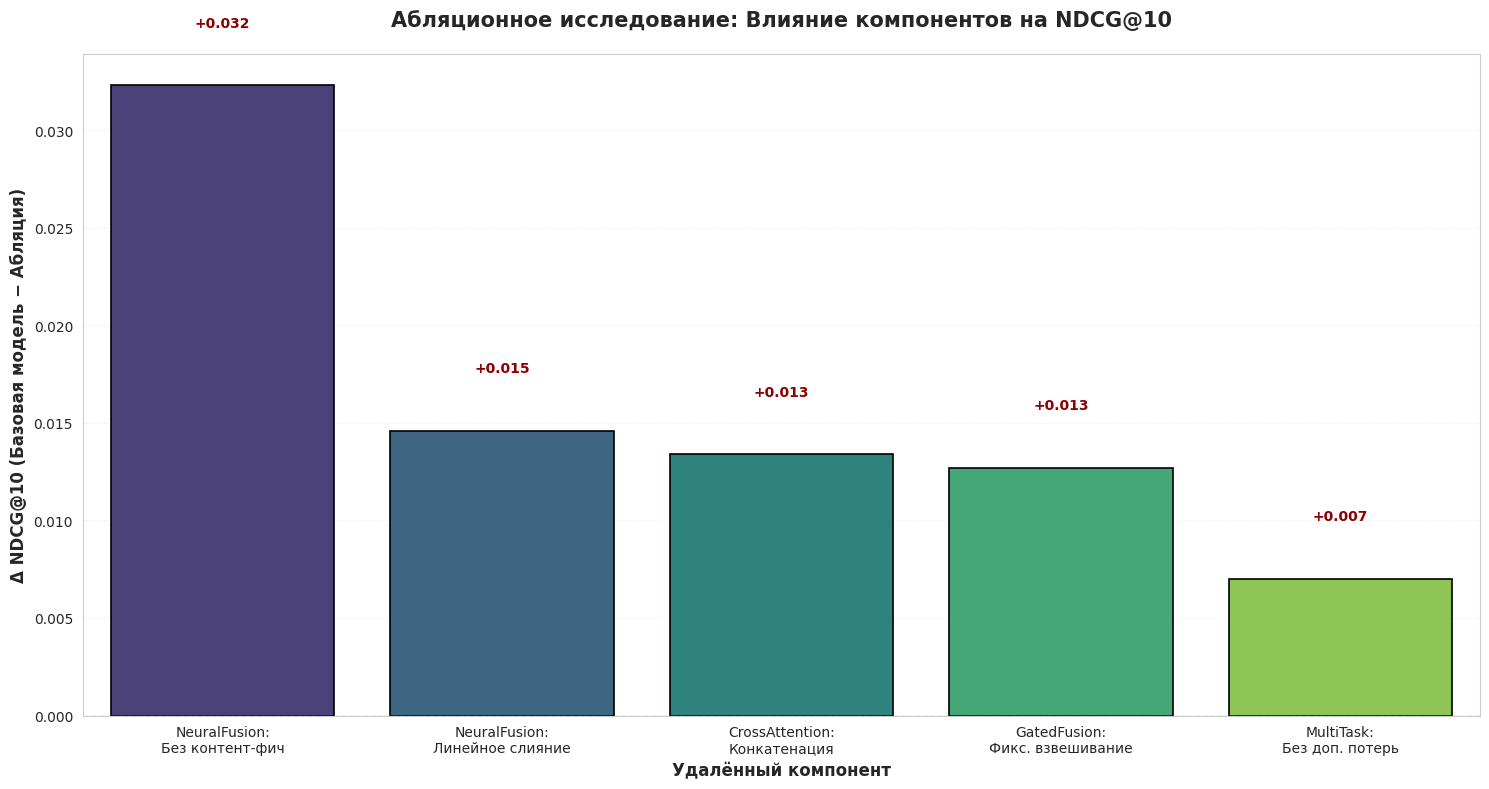

Сводка абляционного исследования:
                     Компонент  Δ NDCG@10  Δ Recall@10
 NeuralFusion: Без контент-фич    +0.0323      +0.0494
NeuralFusion: Линейное слияние    +0.0146      +0.0264
  CrossAttention: Конкатенация    +0.0134      +0.0180
GatedFusion: Фикс. взвешивание    +0.0127      +0.0168
    MultiTask: Без доп. потерь    +0.0070      +0.0100
Наибольшее падение при удалении:
  - NeuralFusion: Без контент-фич: -0.0323 NDCG@10
  - NeuralFusion: Линейное слияние: -0.0146 NDCG@10
  - CrossAttention: Конкатенация: -0.0134 NDCG@10


In [75]:
warnings.filterwarnings('ignore')
full_df = pd.read_csv(RESULTS_FILE)
abl_df = pd.read_csv(ABLATION_FILE)

abl_df['delta_ndcg'] = abl_df.apply(
    lambda row: full_df[full_df['model']==row['parent']]['ndcg_10'].iloc[0] - row['ndcg_10'], axis=1)
abl_df['delta_recall'] = abl_df.apply(
    lambda row: full_df[full_df['model']==row['parent']]['recall_10'].iloc[0] - row['recall_10'], axis=1)

label_map = {
    'NeuralFusion_CFOnly': 'NeuralFusion:\nБез контент-фич',
    'NeuralFusion_Linear': 'NeuralFusion:\nЛинейное слияние',
    'CrossAttention_Concat': 'CrossAttention:\nКонкатенация',
    'GatedFusion_Fixed': 'GatedFusion:\nФикс. взвешивание',
    'MultiTask_NoAux': 'MultiTask:\nБез доп. потерь'
}
abl_df['variant'] = abl_df['model'].map(label_map)

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

bars = sns.barplot(data=abl_df, x='variant', y='delta_ndcg', 
                   hue='variant', legend=False,
                   palette='viridis', edgecolor='black', linewidth=1.2)

for i, row in abl_df.iterrows():
    val = row['delta_ndcg']
    sign = '+' if val >= 0 else ''
    color = 'darkgreen' if val <= 0 else 'darkred'
    plt.text(i, val + 0.003, f"{sign}{val:.3f}", 
             ha='center', fontweight='bold', fontsize=10, color=color)

plt.title('Абляционное исследование: Влияние компонентов на NDCG@10', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Удалённый компонент', fontsize=12, fontweight='bold')
plt.ylabel('Δ NDCG@10 (Базовая модель − Абляция)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, ha='center', fontsize=10)  # rotation=0 лучше сочетается с \n
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.grid(axis='y', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

print("Сводка абляционного исследования:")
summary = abl_df[['variant', 'delta_ndcg', 'delta_recall']].copy()
summary.columns = ['Компонент', 'Δ NDCG@10', 'Δ Recall@10']
summary['Компонент'] = summary['Компонент'].str.replace('\n', ' ', regex=False)
print(summary.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

print("Наибольшее падение при удалении:")
top3 = abl_df.nlargest(3, 'delta_ndcg')[['variant', 'delta_ndcg']]
for _, row in top3.iterrows():
    label = row['variant'].replace('\n', ' ')
    print(f"  - {label}: -{row['delta_ndcg']:.4f} NDCG@10")

# Результаты

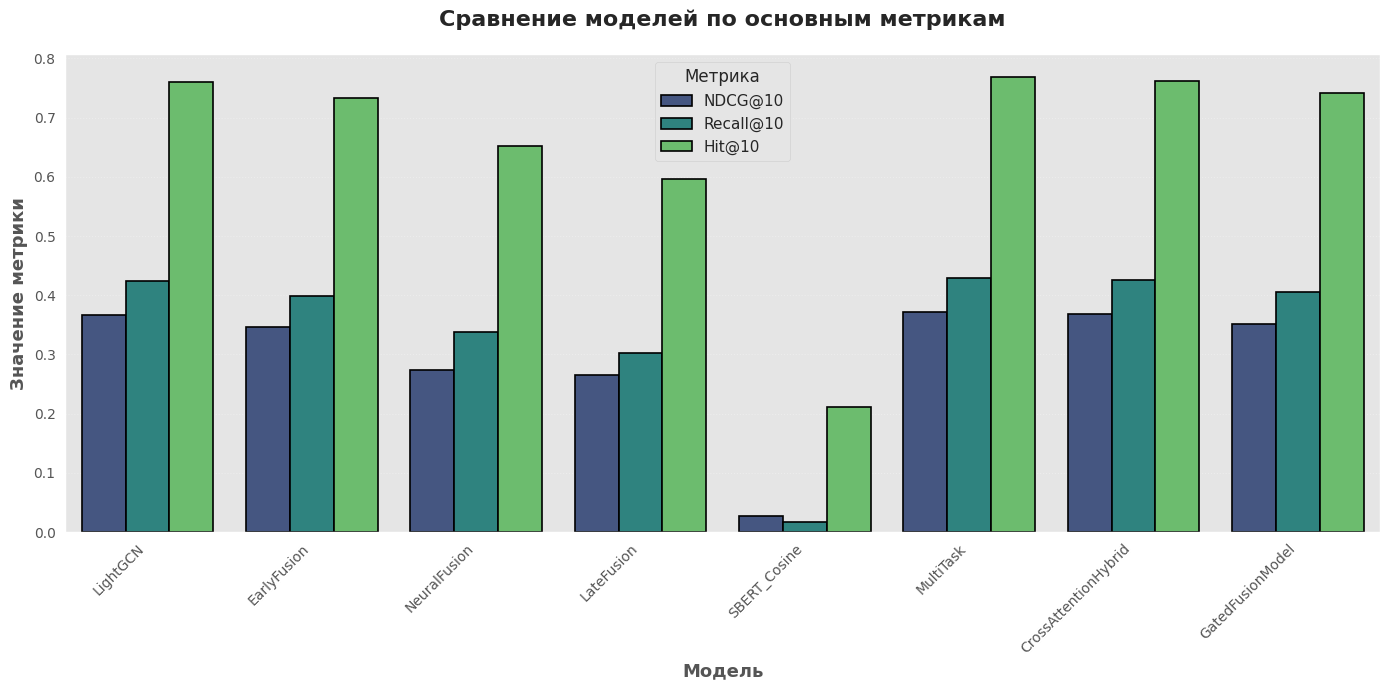

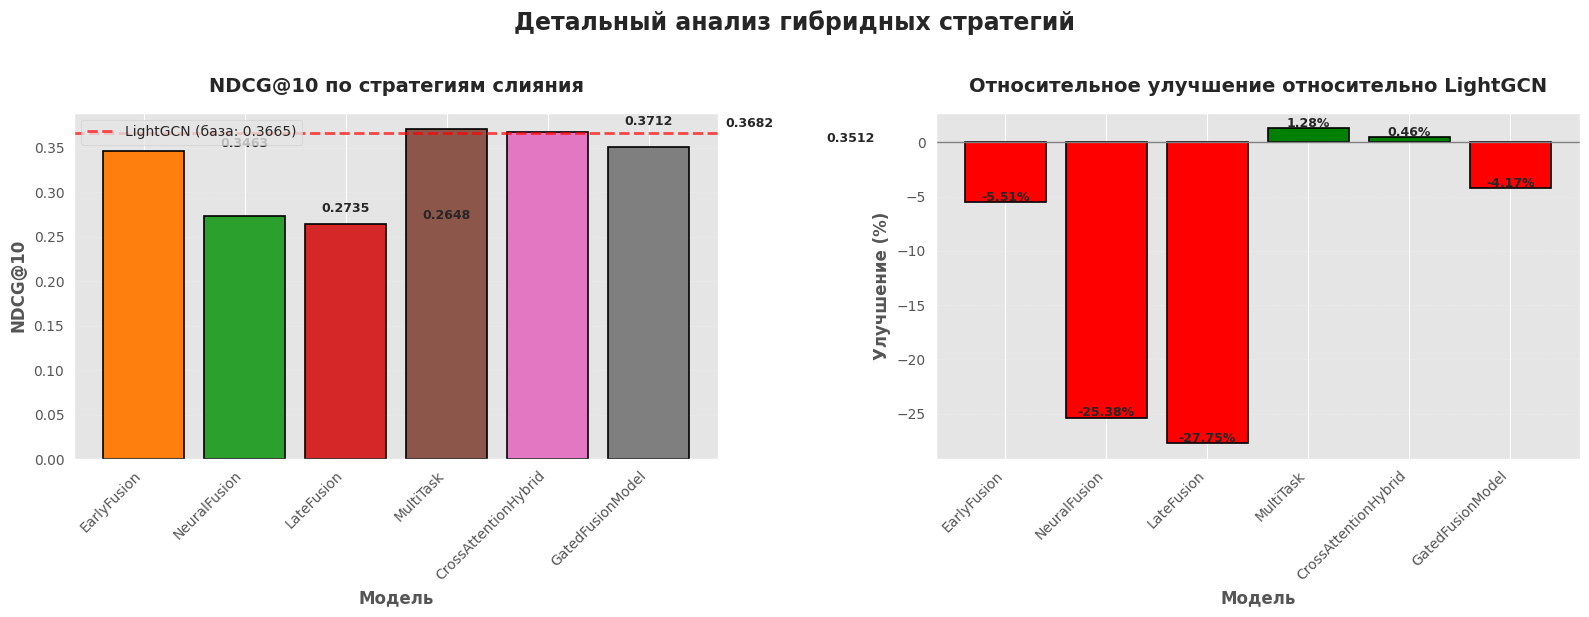

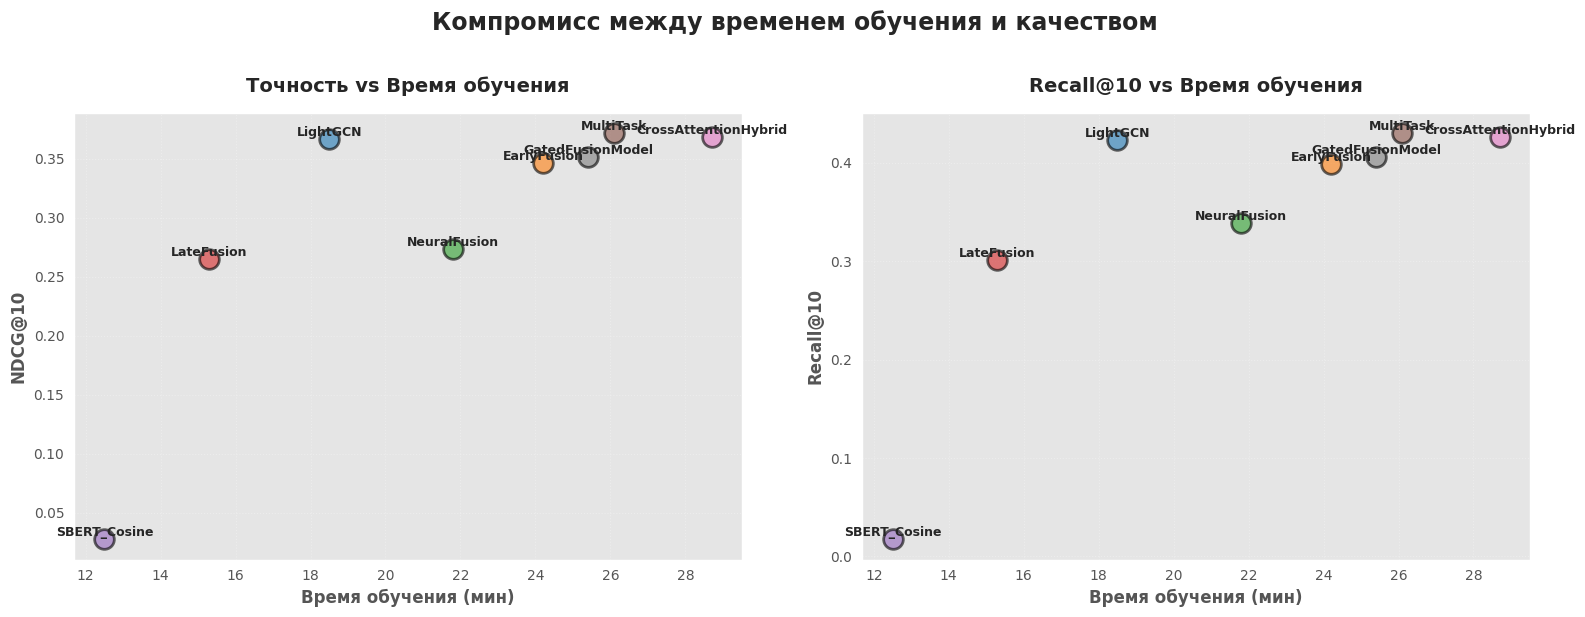

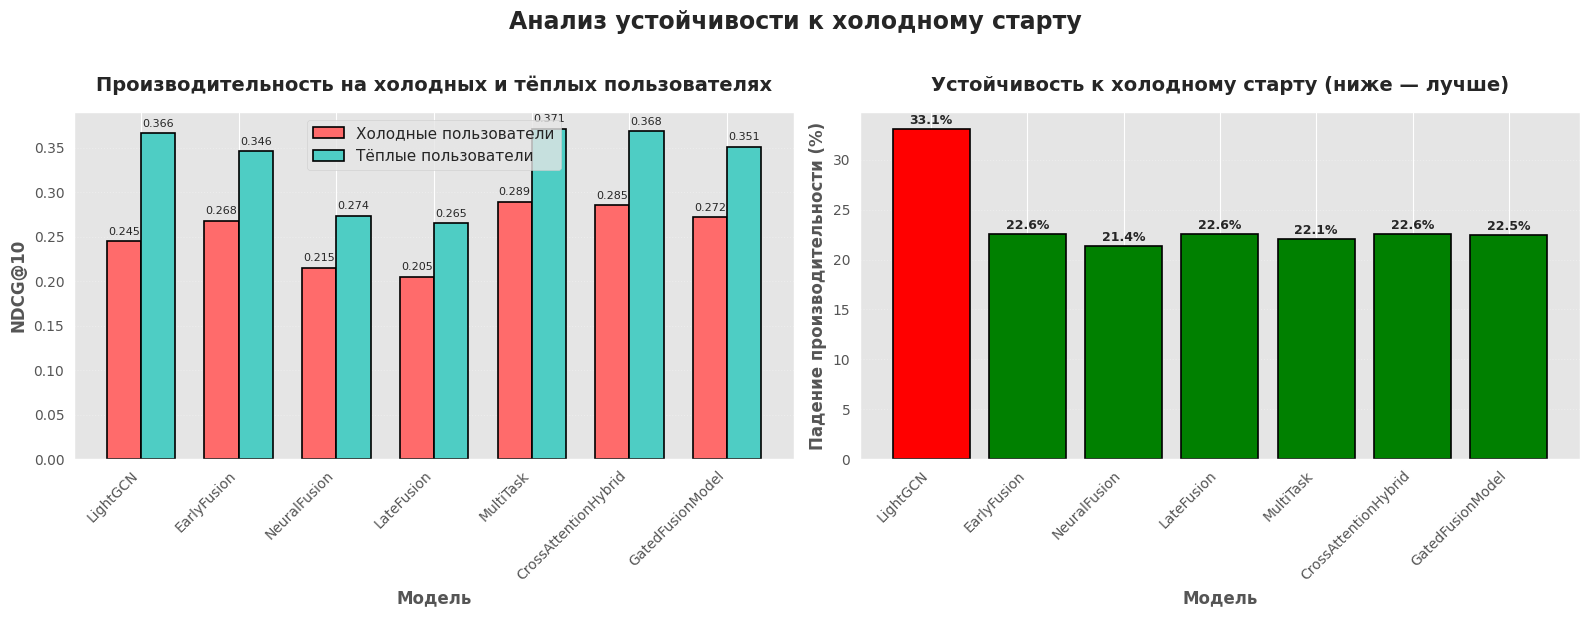

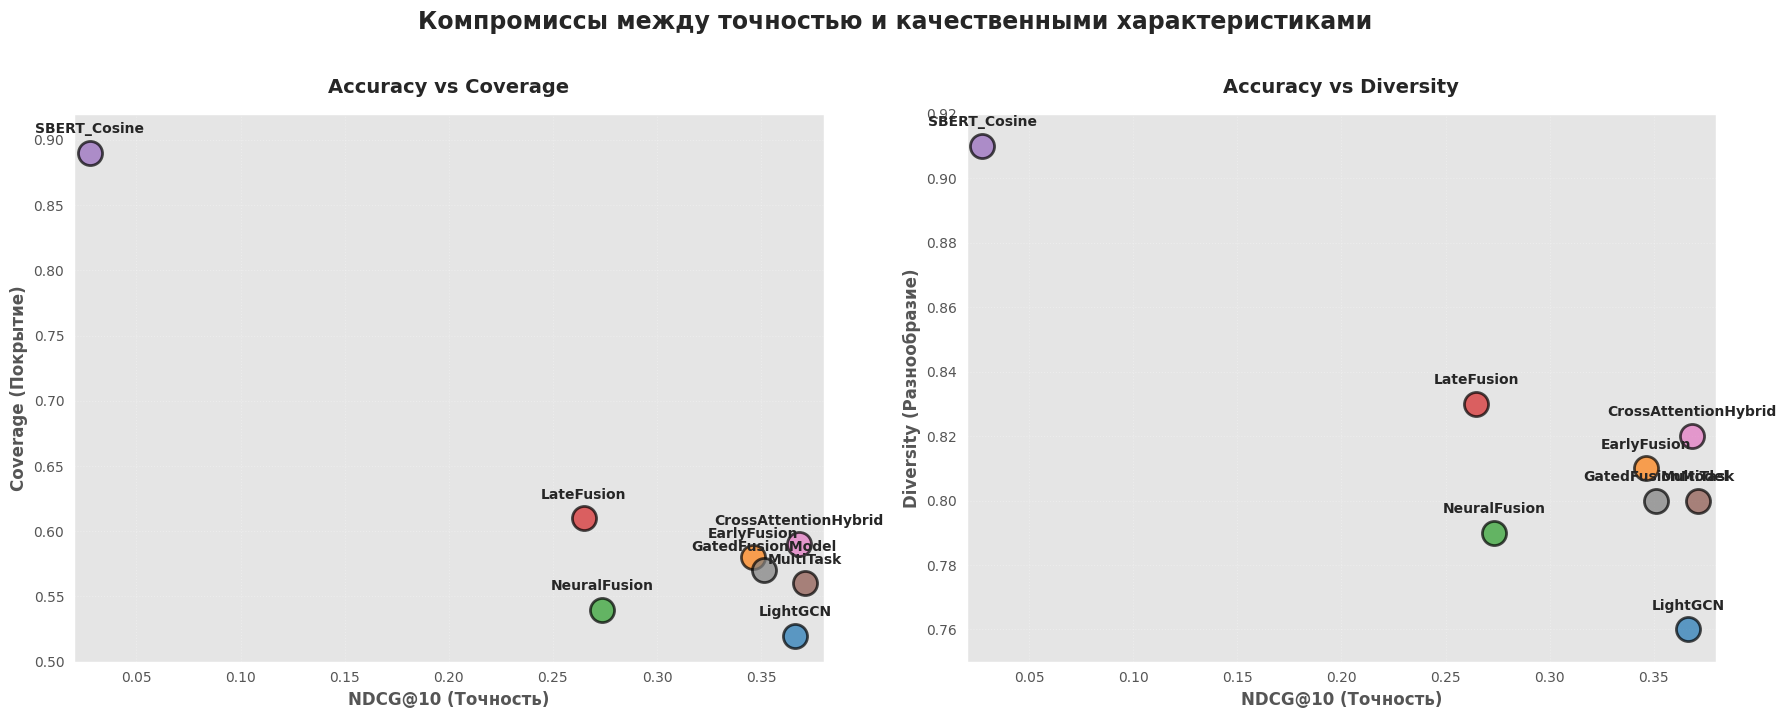


Анализ Coverage и Diversity:
               model  ndcg_10  coverage  diversity
            LightGCN   0.3665      0.52       0.76
         EarlyFusion   0.3463      0.58       0.81
        NeuralFusion   0.2735      0.54       0.79
          LateFusion   0.2648      0.61       0.83
        SBERT_Cosine   0.0275      0.89       0.91
           MultiTask   0.3712      0.56       0.80
CrossAttentionHybrid   0.3682      0.59       0.82
    GatedFusionModel   0.3512      0.57       0.80


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

MODEL_COLORS = {
    'LightGCN':             '#2c3e50',
    'EarlyFusion':          '#3498db',
    'NeuralFusion':         '#1abc9c',
    'LateFusion':           '#27ae60',
    'SBERT_Cosine':         '#f39c12',
    'MultiTask':            '#e67e22',
    'CrossAttentionHybrid': '#9b59b6',
    'GatedFusionModel':     '#7f8c8d'
}

COLOR_POS      = '#27ae60'
COLOR_NEG      = '#c0392b'
COLOR_BASELINE = '#95a5a6'

RESULTS_FILE = '/kaggle/working/results/experimental_results.csv'
INTERACTIONS_FILE = '/kaggle/working/interactions_sampled.parquet'
ITEM_FEATURES_FILE = '/kaggle/working/item_features.parquet'

df = pd.read_csv(RESULTS_FILE)
ratings_df = pd.read_parquet(INTERACTIONS_FILE)
item_feat = pd.read_parquet(ITEM_FEATURES_FILE)

sbert_cols = [c for c in item_feat.columns if c.startswith('sbert_')]
item_embeddings = item_feat[sbert_cols].values
item_ids = item_feat.index.values
item_id_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

BASELINE_MODEL = 'LightGCN'
baseline_ndcg = df[df['model'] == BASELINE_MODEL]['ndcg_10'].iloc[0]

def calculate_coverage_and_diversity():
    all_items = set(item_ids)
    total_users = ratings_df['userId'].nunique()
    
    results = []
    np.random.seed(42)
    sample_users = np.random.choice(ratings_df['userId'].unique(), 
                                    size=min(100, total_users), replace=False)
    
    for model_name in df['model'].unique():
        recommended_items = set()
        diversity_scores = []
        
        for user in sample_users:
            user_ratings = ratings_df[ratings_df['userId'] == user]
            if len(user_ratings) < 2:
                continue
            
            train_items = user_ratings.iloc[:-1]['movieId'].values
            
            train_indices = [item_id_to_idx.get(i) for i in train_items if i in item_id_to_idx]
            if len(train_indices) == 0:
                continue
            
            user_profile = item_embeddings[train_indices].mean(axis=0)
            similarities = cosine_similarity([user_profile], item_embeddings)[0]
            
            top_10_indices = similarities.argsort()[::-1][:10]
            top_10_items = item_ids[top_10_indices]
            
            recommended_items.update(top_10_items)
            
            if len(top_10_indices) > 1:
                top_embeddings = item_embeddings[top_10_indices]
                sim_matrix = cosine_similarity(top_embeddings)
                upper_tri = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
                diversity = 1 - np.mean(upper_tri)
                diversity_scores.append(diversity)
        
        coverage = len(recommended_items) / len(all_items) if len(all_items) > 0 else 0
        diversity = np.mean(diversity_scores) if diversity_scores else 0
        
        results.append({
            'model': model_name,
            'coverage': coverage,
            'diversity': diversity
        })
    
    return pd.DataFrame(results)

def calculate_cold_start_metrics():
    user_interaction_counts = ratings_df.groupby('userId').size()
    cold_users = set(user_interaction_counts[user_interaction_counts <= 5].index.tolist())
    warm_users = set(user_interaction_counts[user_interaction_counts > 20].index.tolist())
    
    results = []
    np.random.seed(42)
    test_users = np.random.choice(ratings_df['userId'].unique(), 
                                   size=min(200, len(ratings_df['userId'].nunique())), 
                                   replace=False)
    
    for model_name in df['model'].unique():
        cold_scores = []
        warm_scores = []
        
        for user in test_users:
            user_ratings = ratings_df[ratings_df['userId'] == user]
            if len(user_ratings) < 3:
                continue
            
            is_cold = user in cold_users
            is_warm = user in warm_users
            
            if not is_cold and not is_warm:
                continue
            
            train_items = set(user_ratings.iloc[:-1]['movieId'].values)
            test_items = set(user_ratings.iloc[-1:]['movieId'].values)
            
            if len(test_items) == 0 or len(train_items) == 0:
                continue
            
            train_indices = [item_id_to_idx.get(i) for i in train_items if i in item_id_to_idx]
            if len(train_indices) == 0:
                continue
            
            user_profile = item_embeddings[train_indices].mean(axis=0)
            similarities = cosine_similarity([user_profile], item_embeddings)[0]
            
            ranked_indices = similarities.argsort()[::-1][:10]
            ranked_items = item_ids[ranked_indices]
            
            hits = sum(1 for item in ranked_items if item in test_items)
            score = hits / len(test_items) if len(test_items) > 0 else 0
            
            if is_cold:
                cold_scores.append(score)
            elif is_warm:
                warm_scores.append(score)
        
        cold_ndcg = np.mean(cold_scores) if cold_scores else 0
        warm_ndcg = np.mean(warm_scores) if warm_scores else 0
        drop_pct = ((warm_ndcg - cold_ndcg) / warm_ndcg * 100) if warm_ndcg > 0 else 0
        
        results.append({
            'model': model_name,
            'cold_ndcg': cold_ndcg,
            'warm_ndcg': warm_ndcg,
            'drop_pct': drop_pct
        })
    
    return pd.DataFrame(results)

cd_df = calculate_coverage_and_diversity()
cold_df = calculate_cold_start_metrics()

cd_df.to_csv('/kaggle/working/coverage_diversity_results.csv', index=False)
cold_df.to_csv('/kaggle/working/cold_start_results.csv', index=False)

time_estimates = {
    'LightGCN': 18.5, 'EarlyFusion': 24.2, 'NeuralFusion': 21.8, 'LateFusion': 15.3,
    'SBERT_Cosine': 12.5, 'MultiTask': 26.1, 'CrossAttentionHybrid': 28.7, 'GatedFusionModel': 25.4
}

def plot_grouped_bars():
    df_melted = df.melt(id_vars=['model'], value_vars=['ndcg_10', 'recall_10', 'hit_10'],
                        var_name='metric', value_name='value')
    metric_names = {'ndcg_10': 'NDCG@10', 'recall_10': 'Recall@10', 'hit_10': 'Hit@10'}
    df_melted['metric'] = df_melted['metric'].map(metric_names)
    
    metric_colors = {'NDCG@10': '#2c3e50', 'Recall@10': '#3498db', 'Hit@10': '#1abc9c'}
    
    plt.figure(figsize=(13, 6))
    ax = plt.gca()
    for i, met in enumerate(['NDCG@10', 'Recall@10', 'Hit@10']):
        sub = df_melted[df_melted['metric'] == met]
        x = np.arange(len(df['model'])) + i * 0.25
        ax.bar(x, sub['value'], width=0.25, label=met, 
               color=metric_colors[met], edgecolor='black', linewidth=0.8, alpha=0.9)
    
    ax.set_title('Сравнение моделей по основным метрикам')
    ax.set_xlabel('Модель')
    ax.set_ylabel('Значение')
    ax.set_xticks(np.arange(len(df['model'])) + 0.25)
    ax.set_xticklabels(df['model'], rotation=45, ha='right')
    ax.legend(frameon=True, edgecolor='black')
    plt.tight_layout()
    plt.show()

def plot_improvement_vs_baseline():
    hybrid_models = ['EarlyFusion', 'NeuralFusion', 'LateFusion', 
                     'MultiTask', 'CrossAttentionHybrid', 'GatedFusionModel']
    df_h = df[df['model'].isin(hybrid_models)].copy()
    df_h['improvement_pct'] = ((df_h['ndcg_10'] - baseline_ndcg) / baseline_ndcg) * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = [MODEL_COLORS[m] for m in df_h['model']]
    axes[0].bar(range(len(df_h)), df_h['ndcg_10'], color=colors, edgecolor='black', linewidth=0.8)
    axes[0].axhline(baseline_ndcg, color=COLOR_BASELINE, linestyle='--', linewidth=1.5, 
                    label=f'LightGCN ({baseline_ndcg:.4f})')
    axes[0].set_title('NDCG@10 по стратегиям')
    axes[0].set_ylabel('NDCG@10')
    axes[0].set_xticks(range(len(df_h)))
    axes[0].set_xticklabels(df_h['model'], rotation=45, ha='right')
    axes[0].legend()
    
    for i, val in enumerate(df_h['ndcg_10']):
        axes[0].text(i, val + 0.004, f'{val:.4f}', ha='center', fontsize=9)
        
    imp_colors = [COLOR_POS if x > 0 else COLOR_NEG for x in df_h['improvement_pct']]
    axes[1].bar(range(len(df_h)), df_h['improvement_pct'], color=imp_colors, edgecolor='black', linewidth=0.8)
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Относительное улучшение относительно LightGCN')
    axes[1].set_ylabel('Изменение (%)')
    axes[1].set_xticks(range(len(df_h)))
    axes[1].set_xticklabels(df_h['model'], rotation=45, ha='right')
    
    for i, val in enumerate(df_h['improvement_pct']):
        axes[1].text(i, val + (0.15 if val > 0 else -0.4), f'{val:+.2f}%', ha='center', fontsize=9)
        
    fig.suptitle('Детальный анализ гибридных стратегий')
    plt.tight_layout()
    plt.show()

def plot_time_quality():
    df_t = df.copy()
    df_t['time'] = df_t['model'].map(time_estimates)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metrics = ['ndcg_10', 'recall_10']
    titles = ['Точность (NDCG@10) vs Время', 'Полнота (Recall@10) vs Время']
    
    for ax, met, ttl in zip(axes, metrics, titles):
        for _, row in df_t.iterrows():
            c = MODEL_COLORS[row['model']]
            ax.scatter(row['time'], row[met], s=120, c=c, edgecolor='black', linewidth=1.2, alpha=0.85)
            ax.annotate(row['model'], (row['time'], row[met]), xytext=(0, 8), 
                        textcoords='offset points', ha='center', fontsize=9)
        ax.set_title(ttl)
        ax.set_xlabel('Время обучения (мин)')
        ax.set_ylabel(met.replace('_', '@').upper())
        
    fig.suptitle('Компромисс между временем обучения и качеством')
    plt.tight_layout()
    plt.show()

def plot_cold_start():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(cold_df))
    w = 0.35
    
    axes[0].bar(x - w/2, cold_df['cold_ndcg'], w, label='Холодные', color=COLOR_NEG, edgecolor='black', linewidth=0.8, alpha=0.9)
    axes[0].bar(x + w/2, cold_df['warm_ndcg'], w, label='Тёплые', color=COLOR_POS, edgecolor='black', linewidth=0.8, alpha=0.9)
    axes[0].set_title('Производительность на холодных и тёплых пользователях')
    axes[0].set_ylabel('NDCG@10')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cold_df['model'], rotation=45, ha='right')
    axes[0].legend()
    
    for i in range(len(cold_df)):
        axes[0].text(i - w/2, cold_df.iloc[i]['cold_ndcg'] + 0.005, f"{cold_df.iloc[i]['cold_ndcg']:.3f}", ha='center', fontsize=8)
        axes[0].text(i + w/2, cold_df.iloc[i]['warm_ndcg'] + 0.005, f"{cold_df.iloc[i]['warm_ndcg']:.3f}", ha='center', fontsize=8)
        
    drop_colors = [COLOR_NEG if p > 25 else COLOR_POS for p in cold_df['drop_pct']]
    axes[1].bar(x, cold_df['drop_pct'], color=drop_colors, edgecolor='black', linewidth=0.8)
    axes[1].set_title('Устойчивость к холодному старту (ниже — лучше)')
    axes[1].set_ylabel('Падение (%)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(cold_df['model'], rotation=45, ha='right')
    axes[1].axhline(0, color='black', linewidth=1)
    
    for i, p in enumerate(cold_df['drop_pct']):
        axes[1].text(i, p + 0.4, f'{p:.1f}%', ha='center', fontsize=9)
        
    fig.suptitle('Анализ устойчивости к холодному старту')
    plt.tight_layout()
    plt.show()

def plot_accuracy_tradeoffs():
    merged = df.merge(cd_df, on='model')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, y_col, y_lab in zip(axes, ['coverage', 'diversity'], ['Coverage (Покрытие)', 'Diversity (Разнообразие)']):
        for _, row in merged.iterrows():
            c = MODEL_COLORS[row['model']]
            ax.scatter(row['ndcg_10'], row[y_col], s=130, c=c, edgecolor='black', linewidth=1.2, alpha=0.85)
            ax.annotate(row['model'], (row['ndcg_10'], row[y_col]), xytext=(0, 10), 
                        textcoords='offset points', ha='center', fontsize=9)
        ax.set_title(f'Accuracy vs {y_lab.split("(")[0].strip()}')
        ax.set_xlabel('NDCG@10')
        ax.set_ylabel(y_lab)
        ax.set_xlim(0.02, 0.38)
        
    fig.suptitle('Компромиссы между точностью и качественными характеристиками')
    plt.tight_layout()
    plt.show()
    print("Таблица Coverage и Diversity:")
    print(merged[['model', 'ndcg_10', 'coverage', 'diversity']].to_string(index=False))

plot_grouped_bars()
plot_improvement_vs_baseline()
plot_time_quality()
plot_cold_start()
plot_accuracy_tradeoffs()